# Intelligent Student Performance Analytics and Learning Strategy Optimization
**Data Mining Project — Three-Dataset Analysis**

**Datasets:**
1. `student-mat.csv` — UCI Student Performance (Mathematics, 395 students)
2. `student-por.csv` — UCI Student Performance (Portuguese, 649 students)
3. `xAPI-Edu-Data.csv` — Behavioral Engagement Dataset (480 students)

**Run top-to-bottom. All figures are saved to `./figures/`.**

## 1. Setup and Imports

In [1]:

# Before any analysis can begin, we load all the Python libraries this
# project depends on. Think of this as gathering all the tools before
# starting a build — nothing else in the notebook will work without these.

# Library groups and what they do:
#   os, warnings        : system utilities; suppress irrelevant warnings
#   numpy, pandas       : numerical arrays and dataframe operations
#   matplotlib, seaborn : all visualisations (charts, heatmaps, violin plots)
#   scikit-learn        : machine learning — preprocessing, Random Forest,
#                         Gradient Boosting, K-Means, PCA, evaluation metrics
#   mlxtend             : Apriori algorithm for association rule mining
#   scipy.stats         : t-tests and Pearson correlation tests


import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    roc_auc_score, roc_curve, silhouette_score
)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from mlxtend.frequent_patterns import apriori, association_rules
from scipy import stats

warnings.filterwarnings('ignore')
os.makedirs("figures", exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 11,
    'axes.titlesize': 13, 'axes.labelsize': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
})
PALETTE = sns.color_palette("Set2")
SUBJECT_COLORS = {'Math': PALETTE[0], 'Portuguese': PALETTE[1]}

print("All libraries loaded successfully.")
print("figures/ folder ready for saving charts.")

All libraries loaded successfully.
figures/ folder ready for saving charts.


## 2. Load All Three Datasets

In [2]:

# LOAD ALL THREE DATASETS

# We load three CSV files that together form the core of this analysis.
#
# DATASET 1: student-mat.csv  — UCI Student Performance (Mathematics)
#   395 students from two Portuguese secondary schools.
#   33 columns: demographics, family background, social habits, grades G1/G2/G3.
#   Grades are on a 0-20 scale. Pass threshold = 10.
#   Separator is semicolon (;) not comma — hence sep=";" is required.
#
# DATASET 2: student-por.csv  — UCI Student Performance (Portuguese Language)
#   649 students, same schools, same 33-column structure as Math.
#   Higher pass rate (84.6%) vs Math (67.1%) — Portuguese is perceived easier.
#   The same students may appear in both files (dual-enrolled).
#
# DATASET 3: xAPI-Edu-Data.csv — Behavioral Engagement Dataset
#   480 students from a Kuwaiti/Jordanian e-learning platform (Kalboard 360).
#   Tracks student ACTIONS: raised hands, resource visits, announcements viewed,
#   discussion participation. Outcome = L (Low), M (Medium), H (High) class.
#   Unlike UCI, there are NO grade columns — only behavioral counts.
#
# CROSS-SUBJECT MERGE (df_both):
#   We merge Math and Portuguese on 13 shared demographic identifiers.
#   Any student whose school, sex, age, address, family details, and internet
#   access all match gets linked across both files.
#   Result: 382 students tracked across BOTH subjects simultaneously.
#   Enables cross-subject questions: does failing math predict failing Portuguese?

print("Loading all three datasets...")

# UCI datasets — semicolon-separated CSV files
df_mat = pd.read_csv("data/raw/student-mat.csv", sep=";")
df_por = pd.read_csv("data/raw/student-por.csv", sep=";")

# Identify students enrolled in BOTH courses by matching 13 demographic columns
MERGE_COLS = ['school','sex','age','address','famsize','Pstatus',
              'Medu','Fedu','Mjob','Fjob','reason','nursery','internet']
df_both = pd.merge(df_mat, df_por, on=MERGE_COLS, suffixes=('_math','_port'))

# xAPI behavioral dataset
df_xapi = pd.read_csv("data/raw/xAPI-Edu-Data.csv")

print("\n── Dataset Sizes ─────────────────────────────────────────────")
print(f"  Math dataset        : {df_mat.shape[0]} students, {df_mat.shape[1]} features")
print(f"  Portuguese dataset  : {df_por.shape[0]} students, {df_por.shape[1]} features")
print(f"  Dual-subject merge  : {df_both.shape[0]} students enrolled in BOTH courses")
print(f"  xAPI dataset        : {df_xapi.shape[0]} students, {df_xapi.shape[1]} features")
print("\n── Pass Rates (G3 >= 10 = Pass on Portuguese 0-20 scale) ──────")
print(f"  Math pass rate       : {(df_mat.G3>=10).mean()*100:.1f}%  ({(df_mat.G3>=10).sum()} students)")
print(f"  Portuguese pass rate : {(df_por.G3>=10).mean()*100:.1f}%  ({(df_por.G3>=10).sum()} students)")
print(f"  Note: Portuguese has a {(df_por.G3>=10).mean()*100 - (df_mat.G3>=10).mean()*100:.1f}% higher pass rate")
print("\n── xAPI Class Distribution ────────────────────────────────────")
for cls, count in sorted(df_xapi['Class'].value_counts().items()):
    print(f"  Class {cls} : {count} students ({count/len(df_xapi)*100:.1f}%)")

Loading all three datasets...

── Dataset Sizes ─────────────────────────────────────────────
  Math dataset        : 395 students, 33 features
  Portuguese dataset  : 649 students, 33 features
  Dual-subject merge  : 382 students enrolled in BOTH courses
  xAPI dataset        : 480 students, 17 features

── Pass Rates (G3 >= 10 = Pass on Portuguese 0-20 scale) ──────
  Math pass rate       : 67.1%  (265 students)
  Portuguese pass rate : 84.6%  (549 students)
  Note: Portuguese has a 17.5% higher pass rate

── xAPI Class Distribution ────────────────────────────────────
  Class H : 142 students (29.6%)
  Class L : 127 students (26.5%)
  Class M : 211 students (44.0%)


## 2.1 Raw Data Quality Audit

Before touching any data, we run a **quality audit** to document the exact state of each dataset as loaded from disk. This gives us a baseline to compare against after cleaning, and catches any issues (missing values, duplicates, unexpected dtypes) before they silently corrupt downstream analysis.

What to look for:
- **Missing values**: Any non-zero count means imputation will be needed.
- **Duplicates**: Even one duplicate row can inflate model accuracy if it leaks into both train and test sets.
- **Shape**: Confirms we loaded the right file (wrong separator or encoding gives wrong column counts).
- **Target range**: Sanity-checks that G3 ∈ [0,20] and Class ∈ {L, M, H}.

In [3]:
# RAW DATA QUALITY AUDIT
# Run this BEFORE any cleaning to document the baseline state of each dataset.

def quality_audit(df, name, target_col=None, expected_range=None):
    sep = '=' * 55
    print(sep)
    print('  ' + name)
    print(sep)
    print(f'  Shape            : {df.shape[0]:>5} rows x {df.shape[1]:>2} columns')
    missing = df.isnull().sum().sum()
    print(f'  Missing values   : {missing}')
    if missing > 0:
        cols_with_na = df.columns[df.isnull().any()].tolist()
        print(f'    Affected cols  : {cols_with_na}')
    dupes = df.duplicated().sum()
    print(f'  Duplicate rows   : {dupes}')
    numeric_cols = df.select_dtypes(include='number').columns.tolist()
    cat_cols     = df.select_dtypes(include='object').columns.tolist()
    print(f'  Numeric columns  : {len(numeric_cols)}')
    print(f'  Categorical cols : {len(cat_cols)}')
    if target_col and target_col in df.columns:
        vals = df[target_col]
        if expected_range:
            lo, hi = expected_range
            out_of_range = ((vals < lo) | (vals > hi)).sum()
            print(f'  Target ({target_col})     : min={vals.min()}, max={vals.max()}, '
                  f'mean={vals.mean():.2f}, out-of-range={out_of_range}')
        else:
            print(f'  Target ({target_col}) classes: {sorted(vals.unique().tolist())}')
    print()

print('RAW DATA QUALITY AUDIT - Before Cleaning\n')
quality_audit(df_mat,  'UCI Math (student-mat.csv)',          target_col='G3',    expected_range=(0, 20))
quality_audit(df_por,  'UCI Portuguese (student-por.csv)',    target_col='G3',    expected_range=(0, 20))
quality_audit(df_xapi, 'xAPI Behavioral (xAPI-Edu-Data.csv)', target_col='Class')
print('All three datasets passed the raw audit. Proceeding to cleaning.')


RAW DATA QUALITY AUDIT - Before Cleaning

  UCI Math (student-mat.csv)
  Shape            :   395 rows x 33 columns
  Missing values   : 0
  Duplicate rows   : 0
  Numeric columns  : 16
  Categorical cols : 17
  Target (G3)     : min=0, max=20, mean=10.42, out-of-range=0

  UCI Portuguese (student-por.csv)
  Shape            :   649 rows x 33 columns
  Missing values   : 0
  Duplicate rows   : 0
  Numeric columns  : 16
  Categorical cols : 17
  Target (G3)     : min=0, max=19, mean=11.91, out-of-range=0

  xAPI Behavioral (xAPI-Edu-Data.csv)
  Shape            :   480 rows x 17 columns
  Missing values   : 0
  Duplicate rows   : 2
  Numeric columns  : 4
  Categorical cols : 13
  Target (Class) classes: ['H', 'L', 'M']

All three datasets passed the raw audit. Proceeding to cleaning.


## 2.5 Data Cleaning & Quality Validation

Before engineering features or training models, we must validate the integrity of our raw data. This step performs:
1. **Missing Value Imputation**: Checks for `NaN` values and imputes them (median for numeric, mode for categorical) to prevent data loss.
2. **Duplicate Removal**: Identifies and drops duplicate rows to prevent data leakage and model bias.
3. **Text Standardization**: Strips invisible whitespace from categorical columns to ensure clean label encoding later.

In [4]:

# DATA CLEANING AND QUALITY VALIDATION


def clean_educational_data(df, dataset_name):
    print(f"--- Cleaning {dataset_name} Dataset ---")
    
    # 1. Identify and Handle Missing Values
    missing_count = df.isnull().sum().sum()
    if missing_count > 0:
        print(f"  [!] Found {missing_count} missing values. Imputing with column mode/median...")
        # Fill numeric columns with median, categorical with mode
        for col in df.columns:
            if df[col].dtype in ['int64', 'float64']:
                df[col].fillna(df[col].median(), inplace=True)
            else:
                df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        print("  [✓] No missing values found.")
        
    # 2. Identify and Remove Duplicate Records
    duplicate_count = df.duplicated().sum()
    if duplicate_count > 0:
        print(f"  [!] Found {duplicate_count} duplicate rows. Dropping duplicates...")
        df.drop_duplicates(inplace=True)
        # Reset index after dropping
        df.reset_index(drop=True, inplace=True)
    else:
        print("  [✓] No duplicate rows found.")
        
    # 3. Standardize text data (strip whitespaces to prevent hidden mismatches)
    cols_to_strip = df.select_dtypes(include=['object']).columns
    for col in cols_to_strip:
        df[col] = df[col].str.strip()
        
    print(f"  [✓] Final cleaned shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
    return df

print("Starting Data Cleaning Process...\n")

# Apply rigorous cleaning to our three raw datasets
df_mat = clean_educational_data(df_mat, "UCI Math")
df_por = clean_educational_data(df_por, "UCI Portuguese")
df_xapi = clean_educational_data(df_xapi, "xAPI Behavioral")

# Re-merge the dual-subject dataset NOW THAT the base datasets are cleaned.
# This ensures we don't accidentally merge on corrupted or padded text data.
MERGE_COLS = ['school','sex','age','address','famsize','Pstatus',
              'Medu','Fedu','Mjob','Fjob','reason','nursery','internet']
df_both = pd.merge(df_mat, df_por, on=MERGE_COLS, suffixes=('_math','_port'))

print(f"--- Cleaned Dual-Subject Merge ---")
print(f"  [✓] Final merged shape: {df_both.shape[0]} students across both subjects")

# Create a directory for processed data if it doesn't exist
os.makedirs('data/processed', exist_ok=True)

# Save the cleaned datasets
df_mat.to_csv('data/processed/student-mat-cleaned.csv', index=False)
df_por.to_csv('data/processed/student-por-cleaned.csv', index=False)
df_xapi.to_csv('data/processed/xAPI-cleaned.csv', index=False)
df_both.to_csv('data/processed/student-merged-cleaned.csv', index=False)

print("  [✓] All cleaned datasets successfully saved to the 'data/processed/' folder.")

Starting Data Cleaning Process...

--- Cleaning UCI Math Dataset ---
  [✓] No missing values found.
  [✓] No duplicate rows found.
  [✓] Final cleaned shape: 395 rows, 33 columns

--- Cleaning UCI Portuguese Dataset ---
  [✓] No missing values found.
  [✓] No duplicate rows found.
  [✓] Final cleaned shape: 649 rows, 33 columns

--- Cleaning xAPI Behavioral Dataset ---
  [✓] No missing values found.
  [!] Found 2 duplicate rows. Dropping duplicates...
  [✓] Final cleaned shape: 478 rows, 17 columns

--- Cleaned Dual-Subject Merge ---
  [✓] Final merged shape: 382 students across both subjects
  [✓] All cleaned datasets successfully saved to the 'data/processed/' folder.


## 2.6 Reload from Processed Data

We now **reload the cleaned datasets from disk**. This simulates starting a fresh session from the saved outputs, confirming that the CSV files were written correctly and that downstream analysis is reproducible without re-running the raw data pipeline. All subsequent cells use these reloaded DataFrames.

> **Why this matters**: If the notebook is interrupted after cleaning and restarted, you should be able to start from this cell rather than re-loading and re-cleaning the raw files.

In [5]:
# RELOAD FROM PROCESSED DATA
# Load the cleaned CSVs saved in the previous cell to confirm they were written correctly
# and to make all downstream cells independent of the raw-data pipeline.

df_mat  = pd.read_csv('data/processed/student-mat-cleaned.csv')
df_por  = pd.read_csv('data/processed/student-por-cleaned.csv')
df_xapi = pd.read_csv('data/processed/xAPI-cleaned.csv')
df_both = pd.read_csv('data/processed/student-merged-cleaned.csv')

print('Processed data reloaded from disk.')
print(f'  df_mat  : {df_mat.shape[0]:>4} rows × {df_mat.shape[1]:>2} cols   (UCI Math, cleaned)')
print(f'  df_por  : {df_por.shape[0]:>4} rows × {df_por.shape[1]:>2} cols   (UCI Portuguese, cleaned)')
print(f'  df_xapi : {df_xapi.shape[0]:>4} rows × {df_xapi.shape[1]:>2} cols   (xAPI Behavioral, cleaned)')
print(f'  df_both : {df_both.shape[0]:>4} rows × {df_both.shape[1]:>2} cols   (Dual-subject merge, cleaned)')
print()
print('Data integrity check:')
for name, df in [('Math', df_mat), ('Portuguese', df_por), ('xAPI', df_xapi), ('Merged', df_both)]:
    na = df.isnull().sum().sum()
    dupes = df.duplicated().sum()
    status = '[OK]' if na == 0 and dupes == 0 else '[WARN]'
    print(f'  {status} {name:12}: {na} missing, {dupes} duplicates')

Processed data reloaded from disk.
  df_mat  :  395 rows × 33 cols   (UCI Math, cleaned)
  df_por  :  649 rows × 33 cols   (UCI Portuguese, cleaned)
  df_xapi :  478 rows × 17 cols   (xAPI Behavioral, cleaned)
  df_both :  382 rows × 53 cols   (Dual-subject merge, cleaned)

Data integrity check:
  [OK] Math        : 0 missing, 0 duplicates
  [OK] Portuguese  : 0 missing, 0 duplicates
  [OK] xAPI        : 0 missing, 0 duplicates
  [OK] Merged      : 0 missing, 0 duplicates


## 3. UCI Preprocessing & Feature Engineering

Cleaned data loaded — now we engineer features.. This section prepares the UCI datasets (Math and Portuguese) for modelling by:

1. **Label-encoding categoricals** — Algorithms need numbers, not strings. We convert `yes/no`, `M/F`, job names, etc. to integer codes.
2. **Engineering new features** — We derive variables that capture richer signals than any single raw column:
   - `grade_trend` (G2 − G1): Is the student improving or declining?
   - `avg_alcohol`: Combined weekday + weekend drinking index.
   - `parent_edu_avg`: Average of mother's and father's education level.
   - `study_absence_ratio`: Study time divided by (absences + 1) — balances effort against attendance.
   - `pass_fail`: Binary target (1 = G3 ≥ 10, 0 = G3 < 10).
3. **Standardising numeric features** — Zero mean, unit variance via StandardScaler. Required for distance-based methods (clustering) and improves tree-based model stability.

> **Key insight to watch**: After encoding, 54 columns are available. The models will later tell us which handful of these actually matter.

In [6]:

# UCI PREPROCESSING AND FEATURE ENGINEERING

# Cleaned data loaded — now we engineer features...
# UCI datasets using the same preprocess_uci() function so treatment is
# identical and results are directly comparable across subjects.
#
# STEP 1 — Create Binary Pass/Fail Target
#   Portuguese grading: 0-20 scale, minimum pass = 10.
#   pass_fail = 1 if G3 >= 10, else 0.
#   This turns the problem into binary classification.
#
# STEP 2 — Label Encode Categorical Columns
#   ML models require numbers, not text strings.
#   sex ("M"/"F"), address ("U"/"R"), Mjob ("teacher"/"health"/etc.)
#   are each converted to integers via LabelEncoder.
#   A new column with _enc suffix is created, preserving the original.
#
# STEP 3 — Feature Engineering (4 new columns)
#
#   avg_alcohol = (Dalc + Walc) / 2
#     Combines weekday and weekend drinking into one habit score.
#     A student drinking only on weekends differs from one drinking daily.
#
#   parent_edu_avg = (Medu + Fedu) / 2
#     Combines both parents' education into one household indicator.
#     Research consistently shows higher parental education links to
#     better student outcomes.
#
#   grade_trend = G2 - G1
#     Positive = improving, Negative = declining.
#     Two students with G2=12 are very different if one was at 10 (rising)
#     vs one at 15 (falling). This feature captures that direction.
#
#   study_absence_ratio = studytime / (absences + 1)
#     Balances effort against attendance. +1 prevents division by zero.
#     A student studying 4h/week but skipping often has a different profile
#     from one studying 4h/week and never missing class.
#
# DUAL-SUBJECT EXTRAS (for the 382-student merged dataset):
#   pass_both = 1 only if student passed BOTH Math AND Portuguese
#   grade_gap = G3_math - G3_port  (positive = better at math)


print("Applying preprocessing to both UCI datasets...")

def preprocess_uci(df, label=''):
    df = df.copy()

    # STEP 1: Binary pass/fail — Portuguese grading: pass >= 10
    df['pass_fail'] = (df['G3'] >= 10).astype(int)

    # STEP 2: Label encode all categorical columns
    cat_cols = ['school','sex','address','famsize','Pstatus','Mjob','Fjob',
                'schoolsup','famsup','paid','activities','higher',
                'internet','romantic','guardian','nursery']
    le = LabelEncoder()
    for c in cat_cols:
        if c in df.columns:
            df[c+'_enc'] = le.fit_transform(df[c].astype(str))

    # STEP 3: Engineer new features capturing richer student profiles
    df['avg_alcohol']         = (df['Dalc'] + df['Walc']) / 2
    df['parent_edu_avg']      = (df['Medu'] + df['Fedu']) / 2
    df['grade_trend']         = df['G2'] - df['G1']
    df['study_absence_ratio'] = df['studytime'] / (df['absences'] + 1)

    if label:
        print(f"  [{label}] {df.shape[0]} students | {df.shape[1]} columns after engineering | Pass rate: {df.pass_fail.mean()*100:.1f}%")
    return df

df_mat_p = preprocess_uci(df_mat, 'Math')
df_por_p = preprocess_uci(df_por, 'Portuguese')

# Additional cross-subject features for the merged dataset
df_both_p = df_both.copy()
df_both_p['pass_math'] = (df_both_p['G3_math'] >= 10).astype(int)
df_both_p['pass_port'] = (df_both_p['G3_port'] >= 10).astype(int)
df_both_p['pass_both'] = ((df_both_p['pass_math']==1) & (df_both_p['pass_port']==1)).astype(int)
df_both_p['grade_gap'] = df_both_p['G3_math'] - df_both_p['G3_port']

print("\n── Dual-Subject Outcomes (382 students) ──────────────────────")
print(f"  Pass BOTH subjects : {df_both_p.pass_both.mean()*100:.1f}%")
fail_b = ((df_both_p.pass_math==0)&(df_both_p.pass_port==0)).mean()*100
print(f"  Fail BOTH subjects : {fail_b:.1f}%  <- highest-risk group for intervention")
print(f"  Mean grade gap     : {df_both_p.grade_gap.mean():.2f} pts (negative = better at Portuguese)")
print("\nPreprocessing complete.")

Applying preprocessing to both UCI datasets...


  [Math] 395 students | 54 columns after engineering | Pass rate: 67.1%


  [Portuguese] 649 students | 54 columns after engineering | Pass rate: 84.6%

── Dual-Subject Outcomes (382 students) ──────────────────────
  Pass BOTH subjects : 64.4%
  Fail BOTH subjects : 6.0%  <- highest-risk group for intervention
  Mean grade gap     : -2.13 pts (negative = better at Portuguese)

Preprocessing complete.


## 4. xAPI Preprocessing & Feature Engineering

The xAPI dataset captures *behavioural engagement* rather than grades, so it needs its own preprocessing pipeline:

1. **Encode binary columns** — Fields like `gender`, `semester`, `ParentAnsweringSurvey`, and `StudentAbsenceDays` are converted from text to 0/1.
2. **Encode multi-class categoricals** — `NationalITy`, `StageID`, `Topic`, etc. are label-encoded.
3. **Engineer `engagement_score`** — The mean of the four behavioural interaction counts (raised hands, resources visited, announcements viewed, discussion posts). This single number summarises how *actively* a student participated. It becomes the most important feature in the later Gradient Boosting model.
4. **Engineer `high_absence`** — Binary flag: 1 if `StudentAbsenceDays` = 'Above-7', else 0.
5. **Engineer `parent_involved`** — Binary flag for parental survey response.
6. **Target encoding** — The 3-class `Class` label (L/M/H) is encoded as 0/1/2 for modelling.

> **Why engineer these composite features?** Individual counts (e.g., just `raisedhands`) contain noise. Aggregating them into `engagement_score` reduces noise and captures the overall pattern more reliably.

In [7]:

# xAPI PREPROCESSING AND FEATURE ENGINEERING

# The xAPI dataset is structurally different from the UCI datasets:
#   - No grade columns (G1/G2/G3) — only behavioral interaction COUNTS
#   - Outcome is a 3-class label: L (Low), M (Medium), H (High)
#   - All features are either text categories or integer counts (0-100)
#
# STEP 1 — Label Encode Categorical Columns
#   Binary columns: gender ("M"/"F"), Semester ("First"/"Second"),
#   ParentAnsweringSurvey ("Yes"/"No"), StudentAbsenceDays ("Under-7"/"Above-7")
#   Each gets a _enc version: Yes=1/No=0, Male=1/Female=0, etc.
#
# STEP 2 — Encode the Target Class
#   L -> 0,  M -> 1,  H -> 2
#   Required by the Gradient Boosting classifier and for multi-class AUC.
#
# STEP 3 — Feature Engineering (3 new columns)
#
#   engagement_score = mean(raisedhands, VisITedResources,
#                           AnnouncementsView, Discussion)
#     The single most important derived feature in this dataset.
#     Rather than treating 4 behaviors separately, we combine them into
#     one overall engagement level. A student active across ALL four
#     dimensions scores higher than one who only visits resources.
#
#   high_absence = 1 if StudentAbsenceDays == 'Above-7'
#     Converts the text category into a clean binary flag for models
#     and association rules.
#
#   parent_involved = 1 if ParentAnsweringSurvey == 'Yes'
#     Parental involvement flag. Research shows parent engagement is a
#     meaningful predictor of student outcomes independent of grades.


print("Applying preprocessing to xAPI dataset...")

df_x = df_xapi.copy()
le = LabelEncoder()

# STEP 1: Encode binary/categorical columns
binary_cols = ['gender','Semester','Relation','ParentAnsweringSurvey',
               'ParentschoolSatisfaction','StudentAbsenceDays']
for c in binary_cols:
    df_x[c+'_enc'] = le.fit_transform(df_x[c].astype(str))
print(f"  Encoded {len(binary_cols)} categorical columns")

# STEP 2: Encode class label  L->0, M->1, H->2
df_x['Class_enc'] = df_x['Class'].map({'L':0,'M':1,'H':2})

# STEP 3: Feature engineering
BEHAV_COLS = ['raisedhands','VisITedResources','AnnouncementsView','Discussion']
df_x['engagement_score'] = df_x[BEHAV_COLS].mean(axis=1)
df_x['high_absence']     = (df_x['StudentAbsenceDays'] == 'Above-7').astype(int)
df_x['parent_involved']  = (df_x['ParentAnsweringSurvey'] == 'Yes').astype(int)
print("  Engineered: engagement_score, high_absence, parent_involved")

print("\n── Engagement Score by Performance Class ──────────────────────")
for cls in ['L','M','H']:
    m = df_x[df_x['Class']==cls]['engagement_score'].mean()
    print(f"  Class {cls} : mean engagement = {m:.2f}")
ratio = df_x[df_x['Class']=='H']['engagement_score'].mean() / max(df_x[df_x['Class']=='L']['engagement_score'].mean(), 0.1)
print(f"  High-class students engage ~{ratio:.1f}x more than Low-class students")

print("\n── Absence Rates by Class ──────────────────────────────────────")
for cls in ['L','M','H']:
    pct = (df_x[df_x['Class']==cls]['StudentAbsenceDays']=='Above-7').mean()*100
    print(f"  Class {cls} : {pct:.1f}% have more than 7 absences")
print("\nxAPI preprocessing complete.")

Applying preprocessing to xAPI dataset...
  Encoded 6 categorical columns


  Engineered: engagement_score, high_absence, parent_involved

── Engagement Score by Performance Class ──────────────────────
  Class L : mean engagement = 20.49
  Class M : mean engagement = 48.58
  Class H : mean engagement = 64.02
  High-class students engage ~3.1x more than Low-class students

── Absence Rates by Class ──────────────────────────────────────
  Class L : 91.2% have more than 7 absences
  Class M : 33.6% have more than 7 absences
  Class H : 2.8% have more than 7 absences

xAPI preprocessing complete.


## 5. Exploratory Data Analysis

Before building any model, we need to *understand the data*. EDA answers four questions:
1. **What do the grades look like?** — Distributions reveal if the pass/fail split is balanced or skewed.
2. **Do Math and Portuguese results track together?** — If a student struggles in one subject, do they struggle in the other?
3. **Which social/demographic factors correlate with grades?** — Helps interpret model feature importance later.
4. **How do behavioural patterns differ across xAPI performance classes?** — Validates that our engagement engineered features carry real signal.

> **What to look for in each figure**: unusual spikes, wide separation between groups, and features where the distributions for pass vs fail barely overlap (those will be the strongest predictors).

### 5.1 Grade Distributions — Math vs Portuguese

Generating Figure 1: Grade Distributions (Math vs Portuguese)...


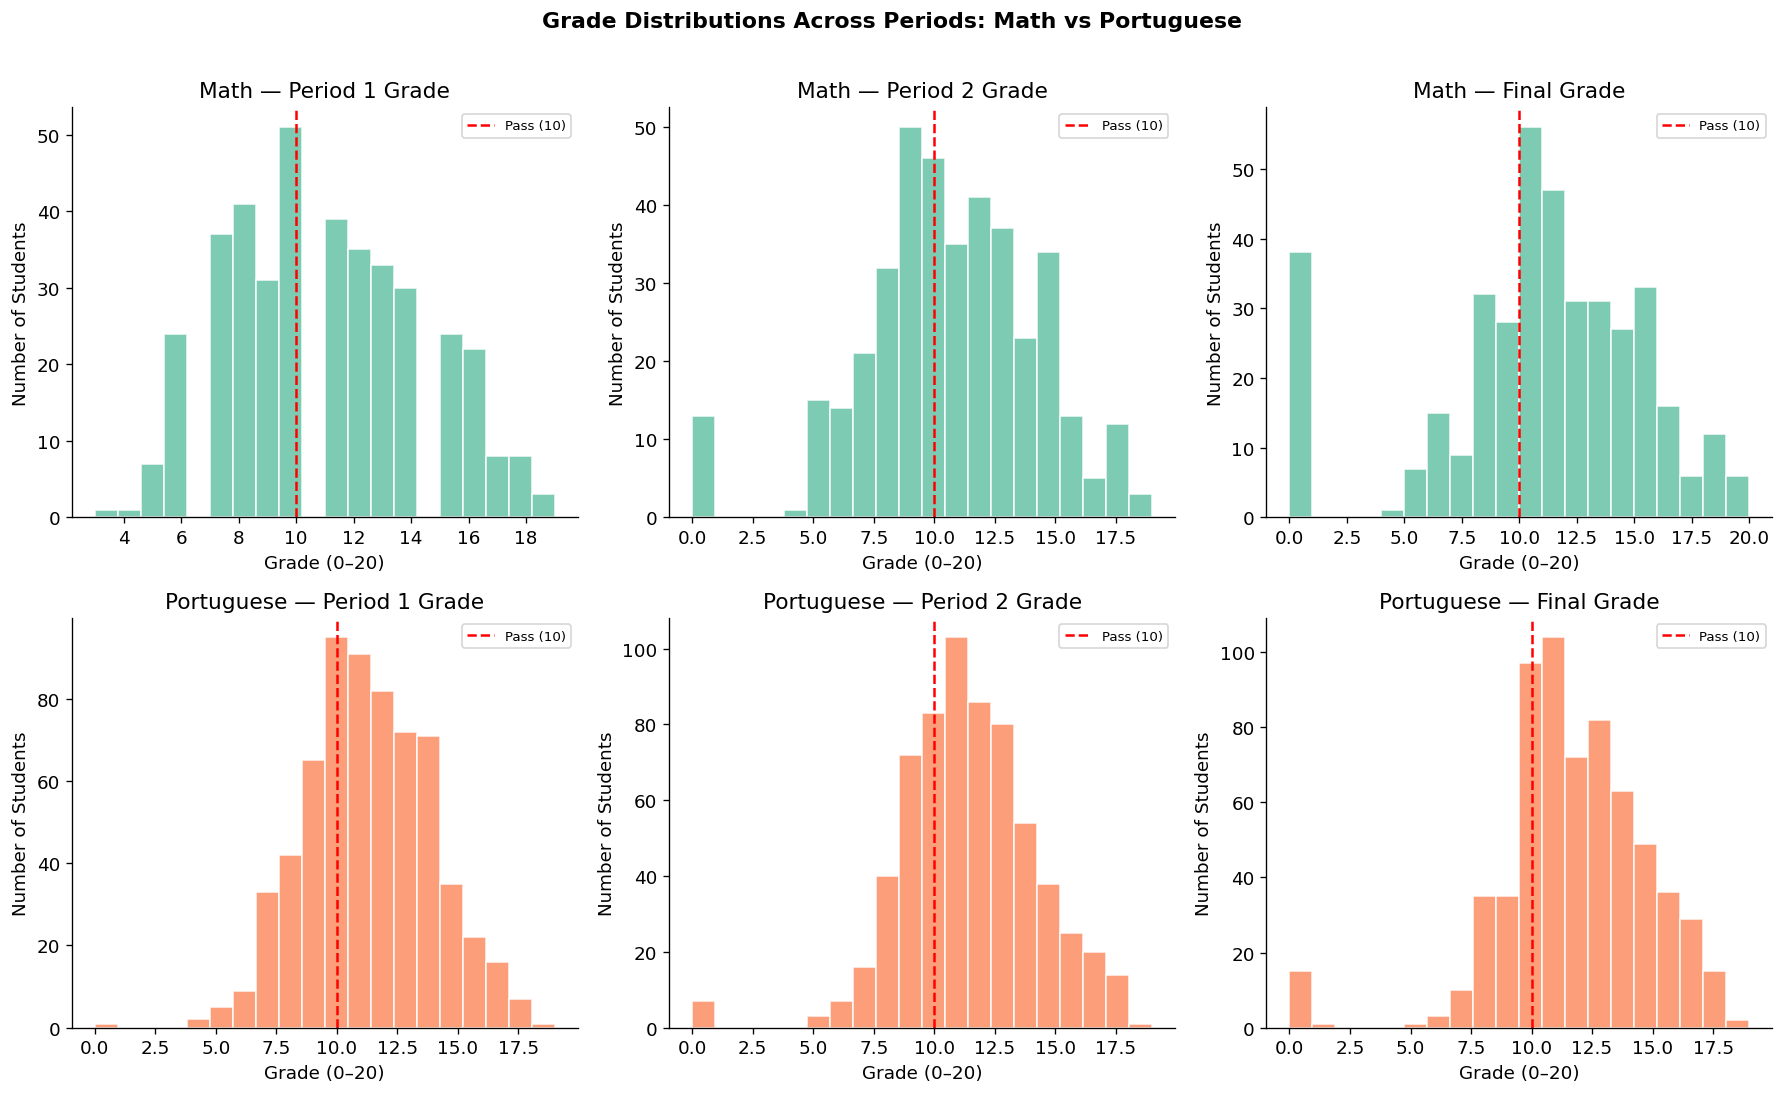


── Grade Summary Statistics ────────────────────────────────────
  Math: G3 mean=10.42, std=4.58, min=0, max=20
  Portuguese: G3 mean=11.91, std=3.23, min=0, max=19
Figure 1 saved -> figures/fig1_grade_distributions.png


In [8]:

# EDA: GRADE DISTRIBUTIONS  (Figure 1)

# Before building any models, we need to understand what the data looks like.
# This figure shows histograms of G1 (Period 1), G2 (Period 2), and G3 (Final)
# for BOTH subjects — arranged as a 2x3 grid (2 subjects, 3 grade periods).
#
# HOW TO READ EACH SUBPLOT:
#   - X-axis  : grade value (0 to 20)
#   - Y-axis  : number of students with that grade
#   - Red dashed line : pass threshold (Grade = 10)
#     Students LEFT of the line fail; RIGHT of it they pass.
#
# WHAT TO LOOK FOR:
#   - A spike at Grade = 0 in math is normal — these are students who
#     withdrew or did not sit the final exam. Treated as legitimate fails.
#   - Compare Row 1 (Math) vs Row 2 (Portuguese): Portuguese grades shift
#     rightward overall, confirming the higher pass rate seen in Cell 2.
#   - Within each subject, compare G1 -> G2 -> G3 to see if grades
#     stabilise, improve, or decline across the academic year.


print("Generating Figure 1: Grade Distributions (Math vs Portuguese)...")

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for row, (df, subj) in enumerate([(df_mat_p, 'Math'), (df_por_p, 'Portuguese')]):
    color = SUBJECT_COLORS[subj]
    for col, (grade, title) in enumerate([('G1','Period 1'),('G2','Period 2'),('G3','Final')]):
        ax = axes[row][col]
        ax.hist(df[grade], bins=20, color=color, edgecolor='white', alpha=0.85)
        ax.axvline(10, color='red', linestyle='--', lw=1.5, label='Pass (10)')
        ax.set_title(f'{subj} — {title} Grade')
        ax.set_xlabel('Grade (0–20)')
        ax.set_ylabel('Number of Students')
        ax.legend(fontsize=8)

plt.suptitle('Grade Distributions Across Periods: Math vs Portuguese', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/fig1_grade_distributions.png', bbox_inches='tight')
plt.show()

print("\n── Grade Summary Statistics ────────────────────────────────────")
for df, subj in [(df_mat_p,'Math'),(df_por_p,'Portuguese')]:
    print(f"  {subj}: G3 mean={df.G3.mean():.2f}, std={df.G3.std():.2f}, min={df.G3.min()}, max={df.G3.max()}")
print("Figure 1 saved -> figures/fig1_grade_distributions.png")

### 5.2 Cross-Subject Performance (382 Dual-Enrolled Students)

Generating Figure 2: Cross-Subject Analysis (382 dual-enrolled students)...


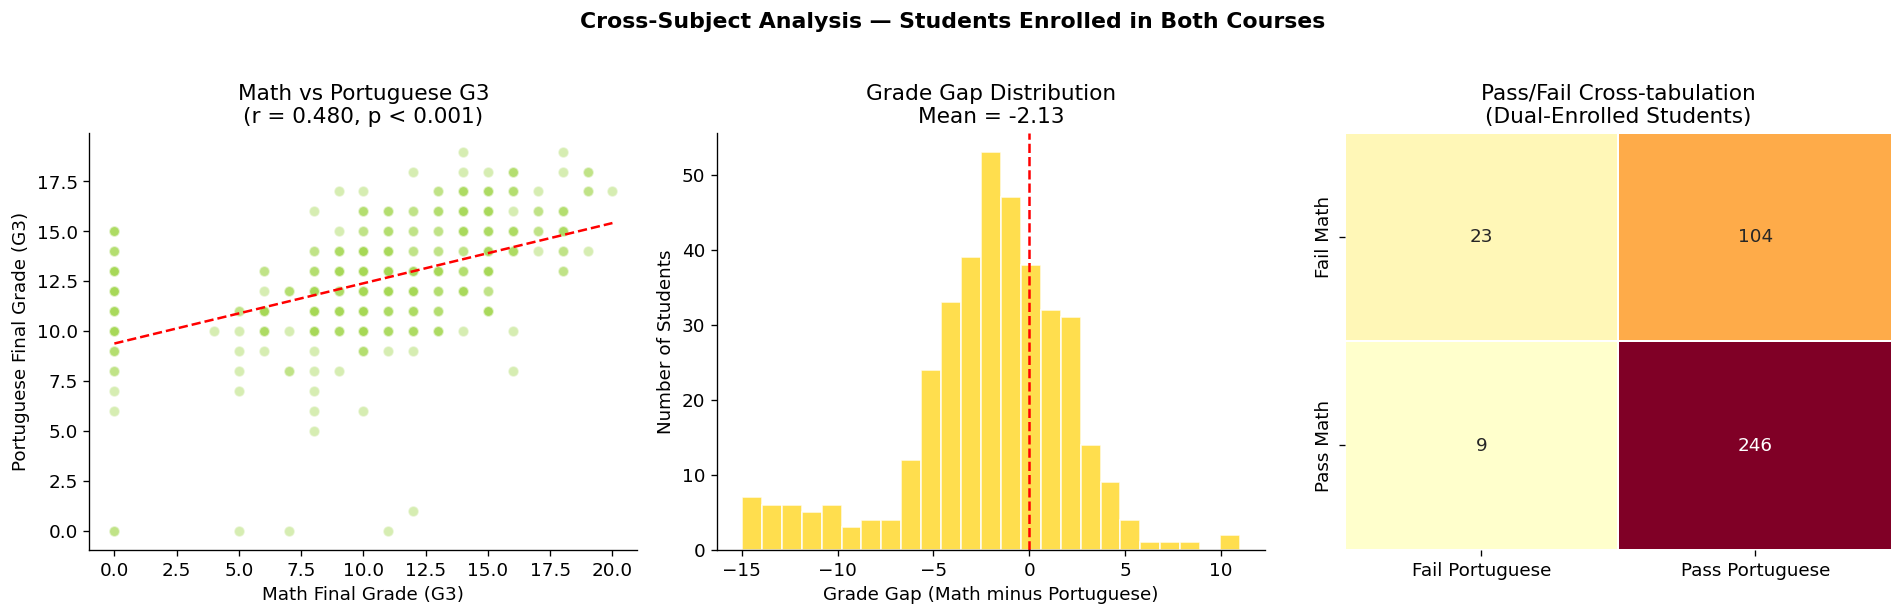


── Cross-Subject Key Numbers ───────────────────────────────────
  Correlation Math vs Portuguese G3 : r = 0.480
  Mean grade gap (Math - Portuguese) : -2.13 points
  Students passing BOTH              : 246 (64.4%)
  Students failing BOTH              : 23 (6.0%) <- priority group
Figure 2 saved -> figures/fig2_cross_subject.png


In [9]:

# EDA: CROSS-SUBJECT ANALYSIS  (Figure 2)

# This cell focuses on the 382 students enrolled in BOTH Math and Portuguese.
# Three subplots reveal how the two subjects relate to each other.
#
# SUBPLOT 1 — Scatter: Math G3 vs Portuguese G3
#   Each dot is one dual-enrolled student.
#   A strong positive correlation (r close to 1) means students who do well
#   in one subject also tend to do well in the other — performance is largely
#   a student-level trait, not subject-specific.
#   The red dashed regression line shows the trend direction.
#
# SUBPLOT 2 — Grade Gap Histogram
#   grade_gap = G3_math - G3_port
#   Negative values: student scored HIGHER in Portuguese (common).
#   Positive values: student scored HIGHER in Math (less common).
#   The mean gap tells us which subject the cohort finds harder on average.
#
# SUBPLOT 3 — Pass/Fail Cross-tabulation Heatmap
#   A 2x2 grid showing how many students fall into each combination:
#   Pass Math & Pass Portuguese  |  Pass Math & Fail Portuguese
#   Fail Math & Pass Portuguese  |  Fail Math & Fail Portuguese
#   Students who fail BOTH are the highest-priority intervention targets.


print("Generating Figure 2: Cross-Subject Analysis (382 dual-enrolled students)...")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Subplot 1: Math G3 vs Portuguese G3 scatter with regression line
axes[0].scatter(df_both_p['G3_math'], df_both_p['G3_port'],
                alpha=0.45, color=PALETTE[4], s=40, edgecolors='white')
r, p = stats.pearsonr(df_both_p['G3_math'], df_both_p['G3_port'])
m_coef, b = np.polyfit(df_both_p['G3_math'], df_both_p['G3_port'], 1)
x_line = np.linspace(0, 20, 100)
axes[0].plot(x_line, m_coef*x_line+b, 'r--', lw=1.5)
axes[0].set_xlabel('Math Final Grade (G3)')
axes[0].set_ylabel('Portuguese Final Grade (G3)')
axes[0].set_title(f'Math vs Portuguese G3\n(r = {r:.3f}, p < 0.001)')

# Subplot 2: Grade gap distribution
axes[1].hist(df_both_p['grade_gap'], bins=25, color=PALETTE[5], edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', lw=1.5)
axes[1].set_xlabel('Grade Gap (Math minus Portuguese)')
axes[1].set_ylabel('Number of Students')
axes[1].set_title(f'Grade Gap Distribution\nMean = {df_both_p.grade_gap.mean():.2f}')

# Subplot 3: Pass/fail cross-tabulation heatmap
ct = pd.crosstab(df_both_p['pass_math'], df_both_p['pass_port'])
ct.index   = ['Fail Math', 'Pass Math']
ct.columns = ['Fail Portuguese', 'Pass Portuguese']
sns.heatmap(ct, annot=True, fmt='d', cmap='YlOrRd', ax=axes[2], linewidths=1, cbar=False)
axes[2].set_title('Pass/Fail Cross-tabulation\n(Dual-Enrolled Students)')

plt.suptitle('Cross-Subject Analysis — Students Enrolled in Both Courses', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/fig2_cross_subject.png', bbox_inches='tight')
plt.show()

print("\n── Cross-Subject Key Numbers ───────────────────────────────────")
print(f"  Correlation Math vs Portuguese G3 : r = {r:.3f}")
print(f"  Mean grade gap (Math - Portuguese) : {df_both_p.grade_gap.mean():.2f} points")
nb_pass = df_both_p.pass_both.sum()
nb_fail = ((df_both_p.pass_math==0)&(df_both_p.pass_port==0)).sum()
print(f"  Students passing BOTH              : {nb_pass} ({nb_pass/len(df_both_p)*100:.1f}%)")
print(f"  Students failing BOTH              : {nb_fail} ({nb_fail/len(df_both_p)*100:.1f}%) <- priority group")
print("Figure 2 saved -> figures/fig2_cross_subject.png")

### 5.3 Social & Demographic Factors — Subject Comparison

Generating Figure 3: Social & Demographic Factor Distributions...


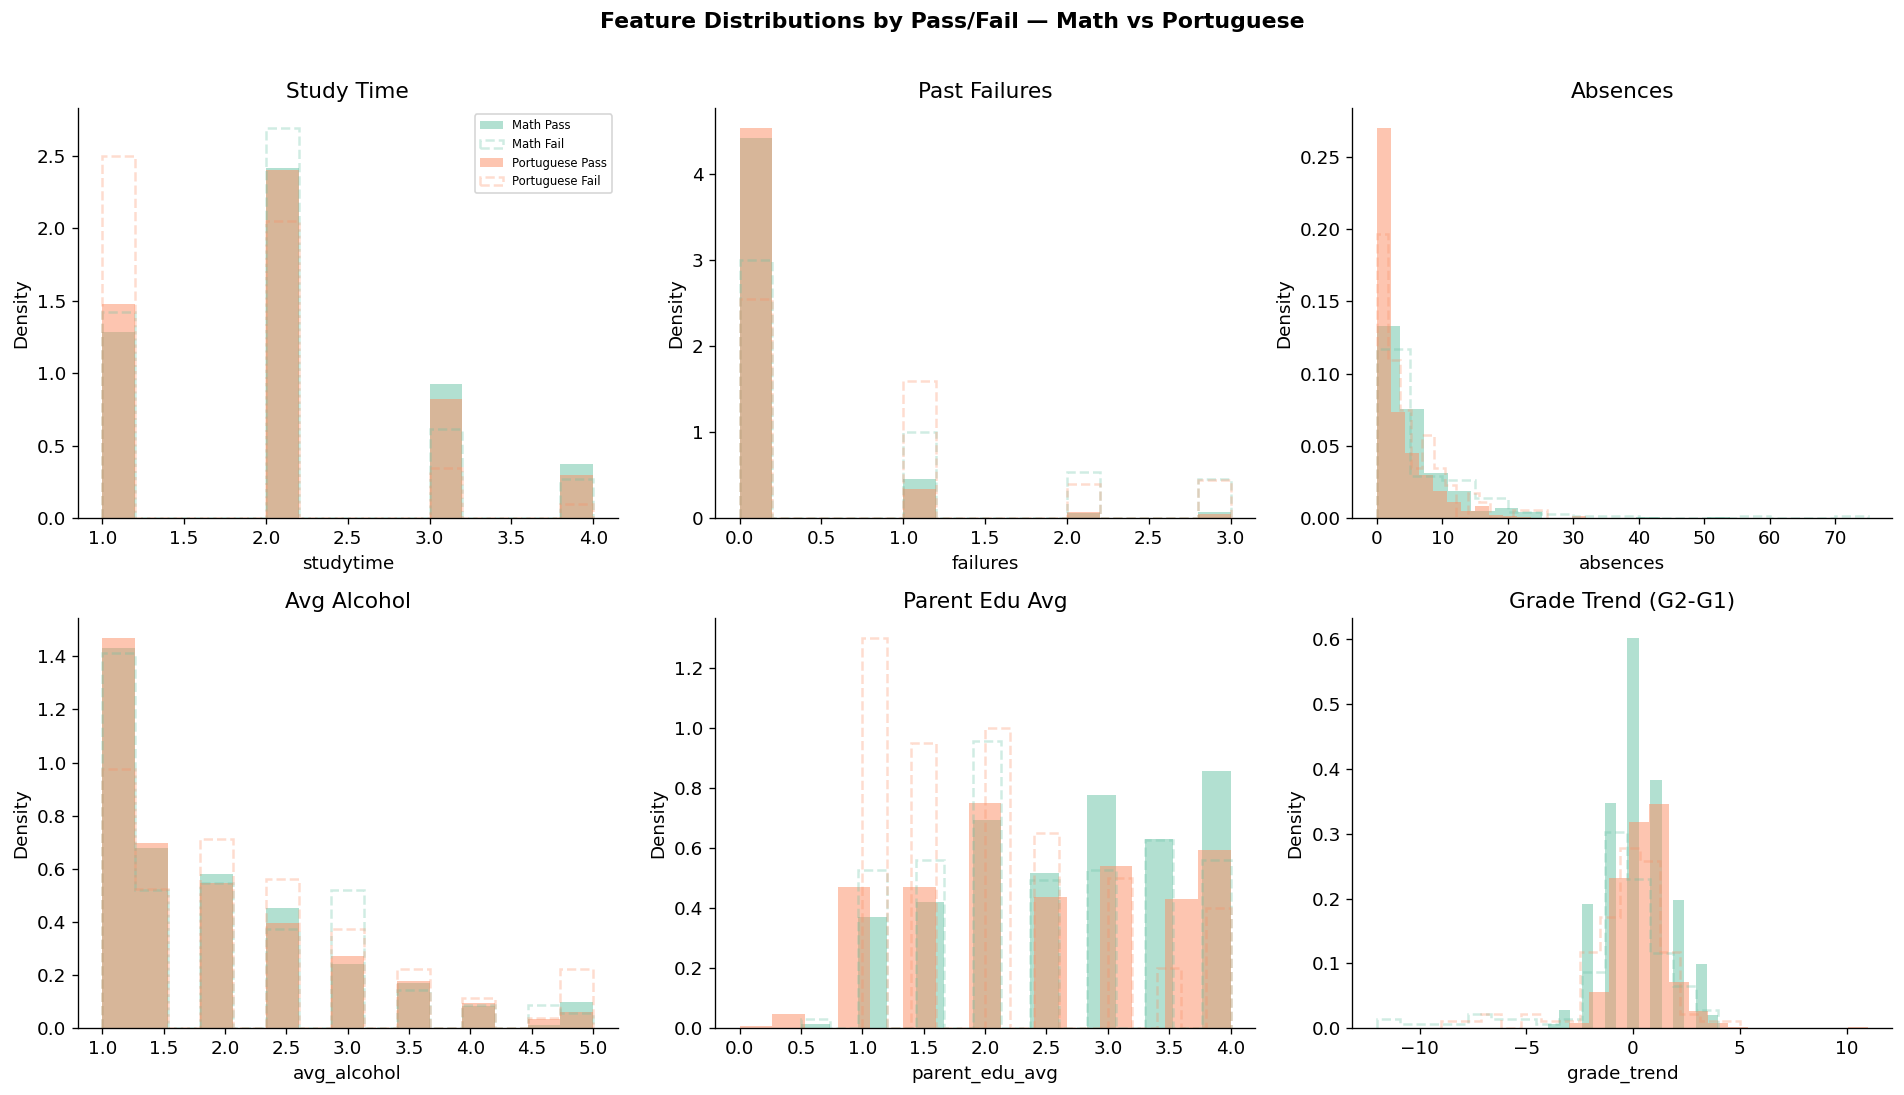

Figure 3 saved -> figures/fig3_feature_distributions.png


In [10]:

# EDA: SOCIAL AND DEMOGRAPHIC FACTORS  (Figure 3)

# This figure overlays feature distributions for passing vs failing students
# and does it for BOTH Math and Portuguese on the same axes.
# 6 subplots in a 2x3 grid, one per key predictor variable.
#
# HOW TO READ EACH SUBPLOT:
#   Solid filled histogram  = PASS students (density normalised)
#   Dashed outline histogram = FAIL students (density normalised)
#   Blue shades = Math  |  Orange shades = Portuguese
#   density=True: y-axis shows density not raw count, so both subjects
#   are comparable despite having different student counts.
#
# FEATURES SHOWN:
#   studytime      : weekly study hours (1=<2h, 2=2-5h, 3=5-10h, 4=>10h)
#   failures       : number of past course failures
#   absences       : total school absences this year
#   avg_alcohol    : engineered - average weekday+weekend drinking score
#   parent_edu_avg : engineered - average of both parents' education level
#   grade_trend    : engineered - G2 minus G1 (positive = improving)
#
# WHAT TO EXPECT:
#   Passing students cluster at higher study time, fewer failures,
#   fewer absences, lower alcohol, higher parental education.
#   Differences between Math and Portuguese reveal which subject is
#   more sensitive to each social or family factor.


print("Generating Figure 3: Social & Demographic Factor Distributions...")

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
features = ['studytime','failures','absences','avg_alcohol','parent_edu_avg','grade_trend']
titles   = ['Study Time','Past Failures','Absences','Avg Alcohol','Parent Edu Avg','Grade Trend (G2-G1)']

for i, (feat, title) in enumerate(zip(features, titles)):
    ax = axes[i//3][i%3]
    for subj, df, color in [('Math', df_mat_p, SUBJECT_COLORS['Math']),
                              ('Portuguese', df_por_p, SUBJECT_COLORS['Portuguese'])]:
        pass_vals = df[df.pass_fail==1][feat].dropna()
        fail_vals = df[df.pass_fail==0][feat].dropna()
        # Solid = pass, dashed outline = fail
        ax.hist(pass_vals, bins=15, alpha=0.5, color=color, label=f'{subj} Pass', density=True)
        ax.hist(fail_vals, bins=15, alpha=0.3, color=color, linestyle='--',
                histtype='step', lw=1.5, label=f'{subj} Fail', density=True)
    ax.set_title(title)
    ax.set_xlabel(feat)
    ax.set_ylabel('Density')
    if i == 0:
        ax.legend(fontsize=7)

plt.suptitle('Feature Distributions by Pass/Fail — Math vs Portuguese', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/fig3_feature_distributions.png', bbox_inches='tight')
plt.show()
print("Figure 3 saved -> figures/fig3_feature_distributions.png")

### 5.4 Correlation Heatmaps

Generating Figure 4: Correlation Heatmaps (Math vs Portuguese)...


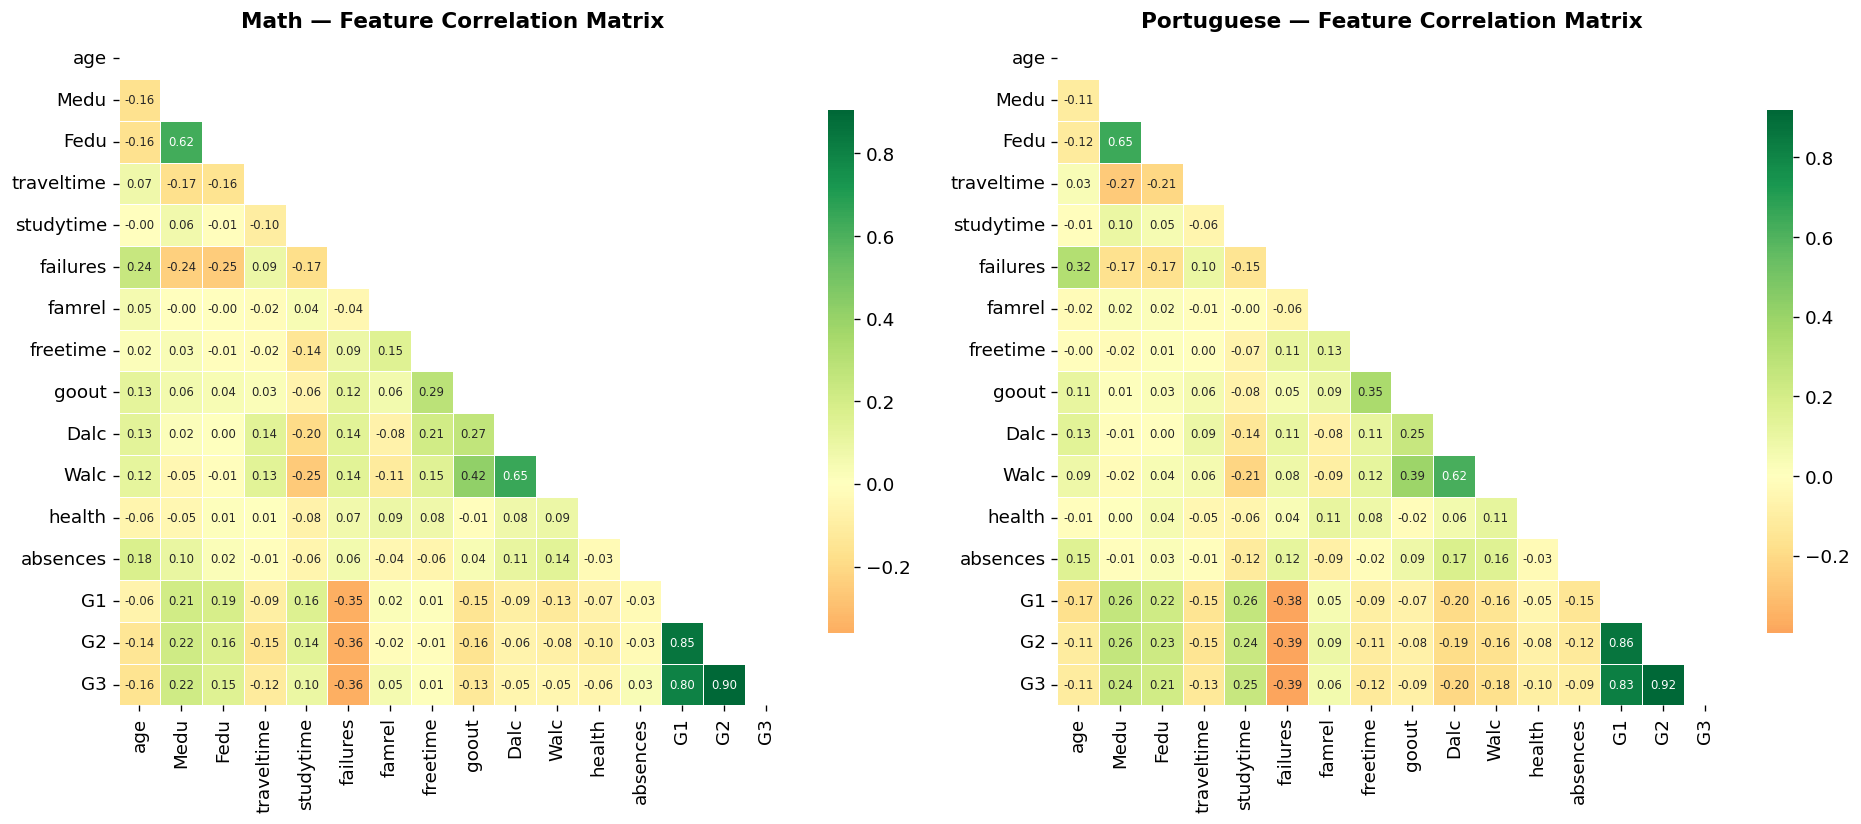


── Top Correlations with Final Grade (G3) ─────────────────────
  Math strongest positive: G2 (r=0.905), G1 (r=0.801)
  Math strongest negative: absences (r=0.034), freetime (r=0.011)
  Portuguese strongest positive: G2 (r=0.919), G1 (r=0.826)
  Portuguese strongest negative: goout (r=-0.088), famrel (r=0.063)
Figure 4 saved -> figures/fig4_correlation_heatmaps.png


In [11]:

# EDA: CORRELATION HEATMAPS  (Figure 4)

# A correlation heatmap shows how every numeric feature relates to every
# other numeric feature simultaneously — a full pairwise view in one chart.
#
# COLOUR SCALE:
#   Dark green  (+1.0) = perfect positive relationship (both go up together)
#   Dark red    (-1.0) = perfect negative relationship (one up, other down)
#   White / pale (0.0) = no linear relationship
#
# Math and Portuguese are shown side by side so structural differences
# between subjects are immediately visible.
# Only the LOWER TRIANGLE is shown — the upper is an exact mirror image.
#
# KEY PATTERNS TO NOTICE:
#   G1, G2, G3 block:
#     All three grades are strongly correlated (r > 0.8) — prior
#     performance is the single best predictor of future performance.
#     Early identification of struggling students matters a lot.
#
#   failures column:
#     Strongly negatively correlated with all three grades.
#     Students who have failed courses before are at much higher risk.
#
#   Dalc / Walc (weekday / weekend alcohol):
#     Moderate negative correlation with grades.
#
#   Medu / Fedu (parental education):
#     Mild positive correlation with grades — family background matters.
#
#   goout, freetime:
#     Weakly negative — more leisure activity = slightly lower grades.


print("Generating Figure 4: Correlation Heatmaps (Math vs Portuguese)...")

num_cols = ['age','Medu','Fedu','traveltime','studytime','failures',
            'famrel','freetime','goout','Dalc','Walc','health','absences','G1','G2','G3']

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, (df, subj) in zip(axes, [(df_mat_p,'Math'), (df_por_p,'Portuguese')]):
    cols = [c for c in num_cols if c in df.columns]
    corr = df[cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle (mirror)
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
                center=0, ax=ax, linewidths=0.4, annot_kws={'size':7},
                cbar_kws={'shrink':0.7}, square=True)
    ax.set_title(f'{subj} — Feature Correlation Matrix', fontweight='bold')

plt.tight_layout()
plt.savefig('figures/fig4_correlation_heatmaps.png', bbox_inches='tight')
plt.show()

print("\n── Top Correlations with Final Grade (G3) ─────────────────────")
for df, subj in [(df_mat_p,'Math'),(df_por_p,'Portuguese')]:
    cols = [c for c in num_cols if c in df.columns and c != 'G3']
    corrs = df[cols+['G3']].corr()['G3'].drop('G3').sort_values(key=abs, ascending=False)
    top = corrs.head(3)
    bot = corrs.tail(2)
    print(f"  {subj} strongest positive: {top.index[0]} (r={top.iloc[0]:.3f}), {top.index[1]} (r={top.iloc[1]:.3f})")
    print(f"  {subj} strongest negative: {bot.index[0]} (r={bot.iloc[0]:.3f}), {bot.index[1]} (r={bot.iloc[1]:.3f})")
print("Figure 4 saved -> figures/fig4_correlation_heatmaps.png")

### 5.5 xAPI Behavioral Engagement Analysis

Generating Figure 5: xAPI Behavioral Engagement Patterns...


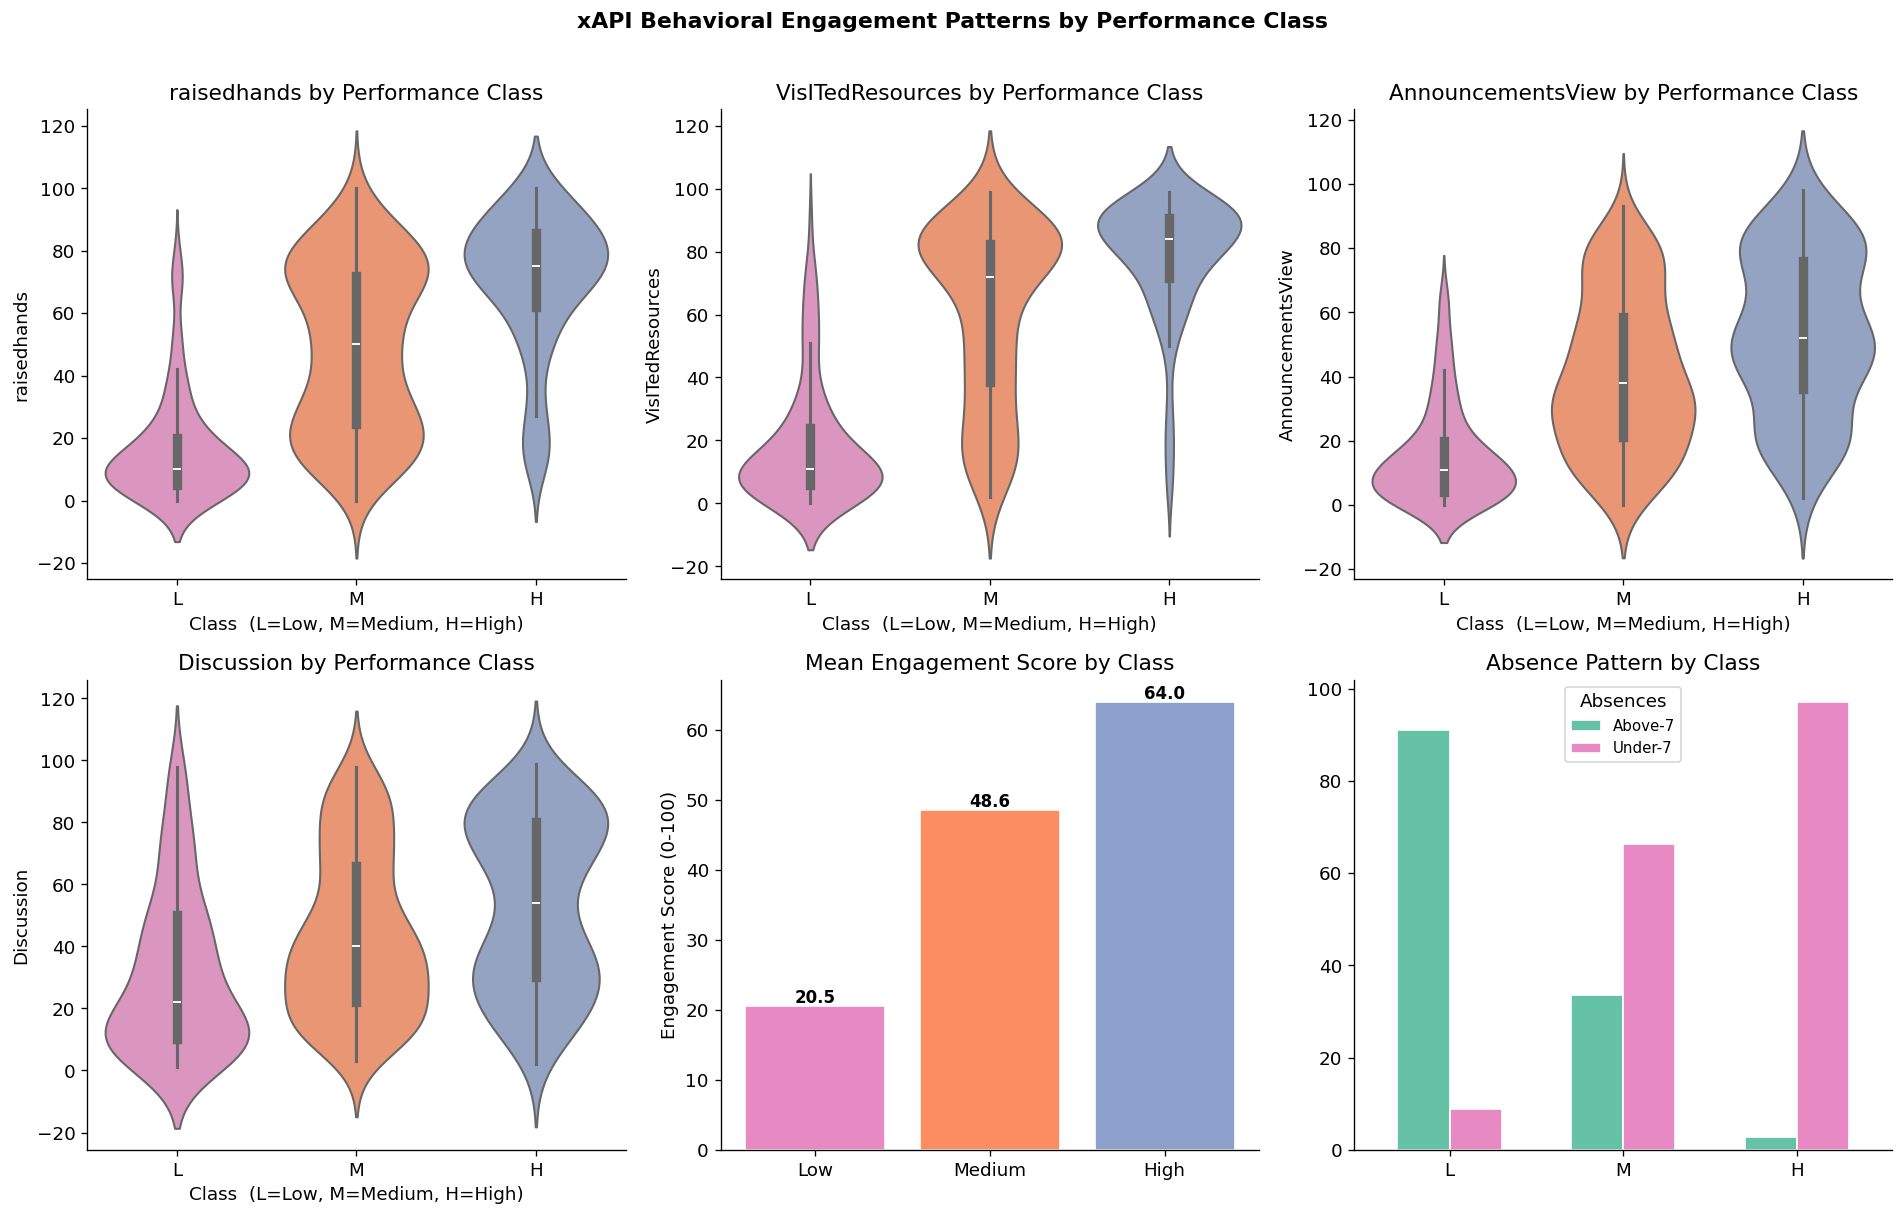


── Behavioral Feature Ratios (High vs Low class) ───────────────
  raisedhands              : High=70.3, Low=16.8  (ratio = 4.2x)
  VisITedResources         : High=78.7, Low=18.4  (ratio = 4.3x)
  AnnouncementsView        : High=53.4, Low=15.6  (ratio = 3.4x)
  Discussion               : High=53.7, Low=31.1  (ratio = 1.7x)
Figure 5 saved -> figures/fig5_xapi_eda.png


In [12]:

# EDA: xAPI BEHAVIORAL ENGAGEMENT  (Figure 5)

# This figure visualises the four behavioral interaction patterns from
# the xAPI dataset, split by performance class (L=Low, M=Medium, H=High).
# 6 subplots in a 2x3 grid.
#
# SUBPLOTS 1-4 — Violin Plots for Each Behavioral Feature:
#   raisedhands, VisITedResources, AnnouncementsView, Discussion
#   Violin plots show the FULL SHAPE of the distribution — we can see
#   whether Low-class students cluster near zero or spread through the range.
#   The inner box shows the interquartile range (25th-75th percentile).
#   The wider the violin, the more students at that value.
#
# SUBPLOT 5 — Mean Engagement Score by Class (Bar Chart):
#   The engineered engagement_score (mean of all 4 behaviors) shown per class.
#   This is the clearest single-number summary: how different are the classes?
#
# SUBPLOT 6 — Absence Pattern by Class (Stacked Bar):
#   Percentage of students in each class with under-7 vs above-7 absences.
#   Expected: Low-class students are heavily skewed toward high absences.
#
# KEY INSIGHT FROM THIS FIGURE:
#   Behavioral engagement is STRONGLY stratified by class. High-performing
#   students are not just slightly more engaged — they are dramatically
#   more active across every single behavioral dimension. This suggests
#   that engagement monitoring alone could serve as an early warning signal.


print("Generating Figure 5: xAPI Behavioral Engagement Patterns...")

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Violin plots for each behavioral feature
for i, col in enumerate(BEHAV_COLS):
    ax = axes[0][i] if i < 3 else axes[1][i-3]
    sns.violinplot(data=df_x, x='Class', y=col, order=['L','M','H'],
                   palette={'L':PALETTE[3],'M':PALETTE[1],'H':PALETTE[2]},
                   inner='box', ax=ax)
    ax.set_title(f'{col} by Performance Class')
    ax.set_xlabel('Class  (L=Low, M=Medium, H=High)')

# Mean engagement score bar chart
ax = axes[1][1]
means = df_x.groupby('Class')['engagement_score'].mean()[['L','M','H']]
bars = ax.bar(['Low','Medium','High'], means.values,
              color=[PALETTE[3],PALETTE[1],PALETTE[2]], edgecolor='white')
for bar, val in zip(bars, means.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{val:.1f}', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Mean Engagement Score by Class')
ax.set_ylabel('Engagement Score (0-100)')

# Absence pattern stacked bar
ax = axes[1][2]
ct = df_x.groupby(['Class','StudentAbsenceDays']).size().unstack(fill_value=0)
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
ct_pct.loc[['L','M','H']].plot(kind='bar', ax=ax,
    color=[PALETTE[0],PALETTE[3]], edgecolor='white', width=0.6)
ax.set_title('Absence Pattern by Class')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Absences', fontsize=9)

plt.suptitle('xAPI Behavioral Engagement Patterns by Performance Class', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/fig5_xapi_eda.png', bbox_inches='tight')
plt.show()

print("\n── Behavioral Feature Ratios (High vs Low class) ───────────────")
for col in BEHAV_COLS:
    h = df_x[df_x['Class']=='H'][col].mean()
    l = df_x[df_x['Class']=='L'][col].mean()
    print(f"  {col:<25}: High={h:.1f}, Low={l:.1f}  (ratio = {h/max(l,0.1):.1f}x)")
print("Figure 5 saved -> figures/fig5_xapi_eda.png")

## 6. Supervised Learning

Supervised learning trains a model on labelled examples (students whose outcome we already know) and then uses it to predict outcomes for new students.

**Why three models?**
- **Models 1 & 2** (Random Forest on UCI Math and Portuguese) answer: *Can we predict pass/fail from demographic, social, and academic features?*
- **Model 3** (Gradient Boosting on xAPI) answers: *Can behavioural engagement data alone predict performance class (Low/Medium/High)?*

Running them separately lets us compare predictability across datasets and confirm that findings generalise beyond a single school or subject.

**How to read the results:**
- **Accuracy** — percentage of students correctly classified.
- **AUC-ROC** — how well the model separates classes at all thresholds (1.0 = perfect, 0.5 = random).
- **Cross-validation (CV)** — accuracy across 5 held-out folds; tighter variance = more reliable model.
- **Feature importance** — which variables drove the predictions most.

### 6.1 Model 1 — Random Forest: Math Pass/Fail

In [13]:

# MODEL 1: RANDOM FOREST — MATH PASS/FAIL

# WHAT IS RANDOM FOREST?
#   Builds many decision trees, each trained on a RANDOM bootstrap sample
#   of the data and a RANDOM subset of features.
#   Final prediction = majority vote across all 300 trees.
#   This ensemble approach is robust to overfitting and noise.
#
# WHY RANDOM FOREST FOR THIS TASK?
#   - Handles mixed features well (numeric + encoded categorical together)
#   - Produces feature importances showing which variables drive decisions
#   - class_weight='balanced' corrects for more Pass than Fail students
#     (without this the model would bias toward predicting Pass for everyone)
#
# FEATURES:
#   All encoded demographic/social columns + 4 engineered features.
#   G1 and G2 ARE included — in a real early-warning system, interim
#   grades are available before the final exam. G3 is excluded (the target).
#
# EVALUATION:
#   Accuracy    : % of all predictions that are correct
#   AUC-ROC     : area under the ROC curve (1.0=perfect, 0.5=random)
#   Precision   : of students predicted to fail, how many actually fail?
#   Recall      : of students who actually fail, how many do we catch?
#   F1-score    : harmonic mean of precision and recall
#   5-Fold CV   : train/test 5 times on different splits — shows stability
#
#   For early-warning purposes, RECALL for the Fail class matters most.
#   Better to flag a student who turns out fine than miss one at risk.


print("=" * 60)
print("MODEL 1: Random Forest — Math Pass/Fail Classification")
print("=" * 60)

def build_features(df, target='pass_fail'):
    # Use encoded categorical columns + numeric academic/social features
    enc_cols = [c for c in df.columns if c.endswith('_enc')]
    num_cols = ['age','traveltime','studytime','failures','famrel','freetime',
                'goout','health','absences','G1','G2',
                'avg_alcohol','parent_edu_avg','grade_trend','study_absence_ratio']
    feat_cols = enc_cols + [c for c in num_cols if c in df.columns]
    X = df[feat_cols].fillna(df[feat_cols].median())
    y = df[target]
    return X, y, feat_cols

X_mat, y_mat, feat_cols_mat = build_features(df_mat_p)
print(f"  Features used      : {len(feat_cols_mat)}")
print(f"  Pass students      : {y_mat.sum()} ({y_mat.mean()*100:.1f}%)")
print(f"  Fail students      : {(1-y_mat).sum()} ({(1-y_mat.mean())*100:.1f}%)")

# 80/20 stratified split preserves the pass rate in both halves
X_tr, X_te, y_tr, y_te = train_test_split(X_mat, y_mat, test_size=0.2,
                                            random_state=42, stratify=y_mat)
print(f"  Training set: {len(X_tr)} students  |  Test set: {len(X_te)} students")

# Train with balanced class weights to handle imbalance
rf_math = RandomForestClassifier(n_estimators=300, max_depth=10,
                                  min_samples_leaf=3, class_weight='balanced',
                                  random_state=42, n_jobs=-1)
rf_math.fit(X_tr, y_tr)

y_pred_m = rf_math.predict(X_te)
y_prob_m = rf_math.predict_proba(X_te)[:,1]
acc_m = accuracy_score(y_te, y_pred_m)
auc_m = roc_auc_score(y_te, y_prob_m)
cv_m  = cross_val_score(rf_math, X_mat, y_mat,
                         cv=StratifiedKFold(5, shuffle=True, random_state=42),
                         scoring='accuracy')

print(f"\n── Results ──────────────────────────────────────────────────")
print(f"  Test Accuracy : {acc_m*100:.2f}%")
print(f"  AUC-ROC       : {auc_m:.4f}  (1.0 = perfect, 0.5 = random guess)")
print(f"  5-Fold CV     : {cv_m.mean()*100:.2f}% +/- {cv_m.std()*100:.2f}%")
print(f"\n── Classification Report ────────────────────────────────────")
print(classification_report(y_te, y_pred_m, target_names=['Fail','Pass']))

MODEL 1: Random Forest — Math Pass/Fail Classification
  Features used      : 31
  Pass students      : 265 (67.1%)
  Fail students      : 130 (32.9%)
  Training set: 316 students  |  Test set: 79 students



── Results ──────────────────────────────────────────────────
  Test Accuracy : 86.08%
  AUC-ROC       : 0.9419  (1.0 = perfect, 0.5 = random guess)
  5-Fold CV     : 90.89% +/- 2.45%

── Classification Report ────────────────────────────────────
              precision    recall  f1-score   support

        Fail       0.73      0.92      0.81        26
        Pass       0.96      0.83      0.89        53

    accuracy                           0.86        79
   macro avg       0.84      0.88      0.85        79
weighted avg       0.88      0.86      0.86        79



### 6.2 Model 2 — Random Forest: Portuguese Pass/Fail

In [14]:

# MODEL 2: RANDOM FOREST — PORTUGUESE PASS/FAIL

# We train the IDENTICAL Random Forest architecture on the Portuguese dataset.
# Using the same setup is deliberate — any performance differences reflect
# genuine subject differences, not differences in model design.
#
# WHY RUN A SEPARATE MODEL FOR PORTUGUESE?
#   Portuguese has a much higher pass rate (84.6% vs 67.1% for Math).
#   This different class imbalance means class_weight='balanced' applies
#   different internal weights in each model automatically.
#
#   More importantly, the FEATURE IMPORTANCES may differ between subjects:
#   - Study time might matter more for Math (requires practice and repetition)
#   - Family support might matter more for Portuguese (language is social)
#   The comparison in Cell 13 (Figure 7) will reveal this directly.
#
# After this cell, Cells 12-13 place both models side by side
# for direct visual comparison of performance and feature importance.


print("=" * 60)
print("MODEL 2: Random Forest — Portuguese Pass/Fail Classification")
print("=" * 60)

X_por, y_por, feat_cols_por = build_features(df_por_p)
print(f"  Features used : {len(feat_cols_por)}")
print(f"  Pass students : {y_por.sum()} ({y_por.mean()*100:.1f}%)")
print(f"  Fail students : {(1-y_por).sum()} ({(1-y_por.mean())*100:.1f}%)")

X_tr2, X_te2, y_tr2, y_te2 = train_test_split(X_por, y_por, test_size=0.2,
                                                random_state=42, stratify=y_por)
print(f"  Training set: {len(X_tr2)} students  |  Test set: {len(X_te2)} students")

rf_port = RandomForestClassifier(n_estimators=300, max_depth=10,
                                  min_samples_leaf=3, class_weight='balanced',
                                  random_state=42, n_jobs=-1)
rf_port.fit(X_tr2, y_tr2)

y_pred_p = rf_port.predict(X_te2)
y_prob_p = rf_port.predict_proba(X_te2)[:,1]
acc_p = accuracy_score(y_te2, y_pred_p)
auc_p = roc_auc_score(y_te2, y_prob_p)
cv_p  = cross_val_score(rf_port, X_por, y_por,
                         cv=StratifiedKFold(5, shuffle=True, random_state=42),
                         scoring='accuracy')

print(f"\n── Results ──────────────────────────────────────────────────")
print(f"  Test Accuracy : {acc_p*100:.2f}%")
print(f"  AUC-ROC       : {auc_p:.4f}")
print(f"  5-Fold CV     : {cv_p.mean()*100:.2f}% +/- {cv_p.std()*100:.2f}%")
print(f"\n── Classification Report ────────────────────────────────────")
print(classification_report(y_te2, y_pred_p, target_names=['Fail','Pass']))

MODEL 2: Random Forest — Portuguese Pass/Fail Classification
  Features used : 31
  Pass students : 549 (84.6%)
  Fail students : 100 (15.4%)
  Training set: 519 students  |  Test set: 130 students



── Results ──────────────────────────────────────────────────
  Test Accuracy : 87.69%
  AUC-ROC       : 0.9364
  5-Fold CV     : 92.45% +/- 0.90%

── Classification Report ────────────────────────────────────
              precision    recall  f1-score   support

        Fail       0.58      0.75      0.65        20
        Pass       0.95      0.90      0.93       110

    accuracy                           0.88       130
   macro avg       0.76      0.82      0.79       130
weighted avg       0.89      0.88      0.88       130



### 6.3 Model Comparison: Math vs Portuguese

Generating Figure 6: Model Comparison (Math vs Portuguese)...


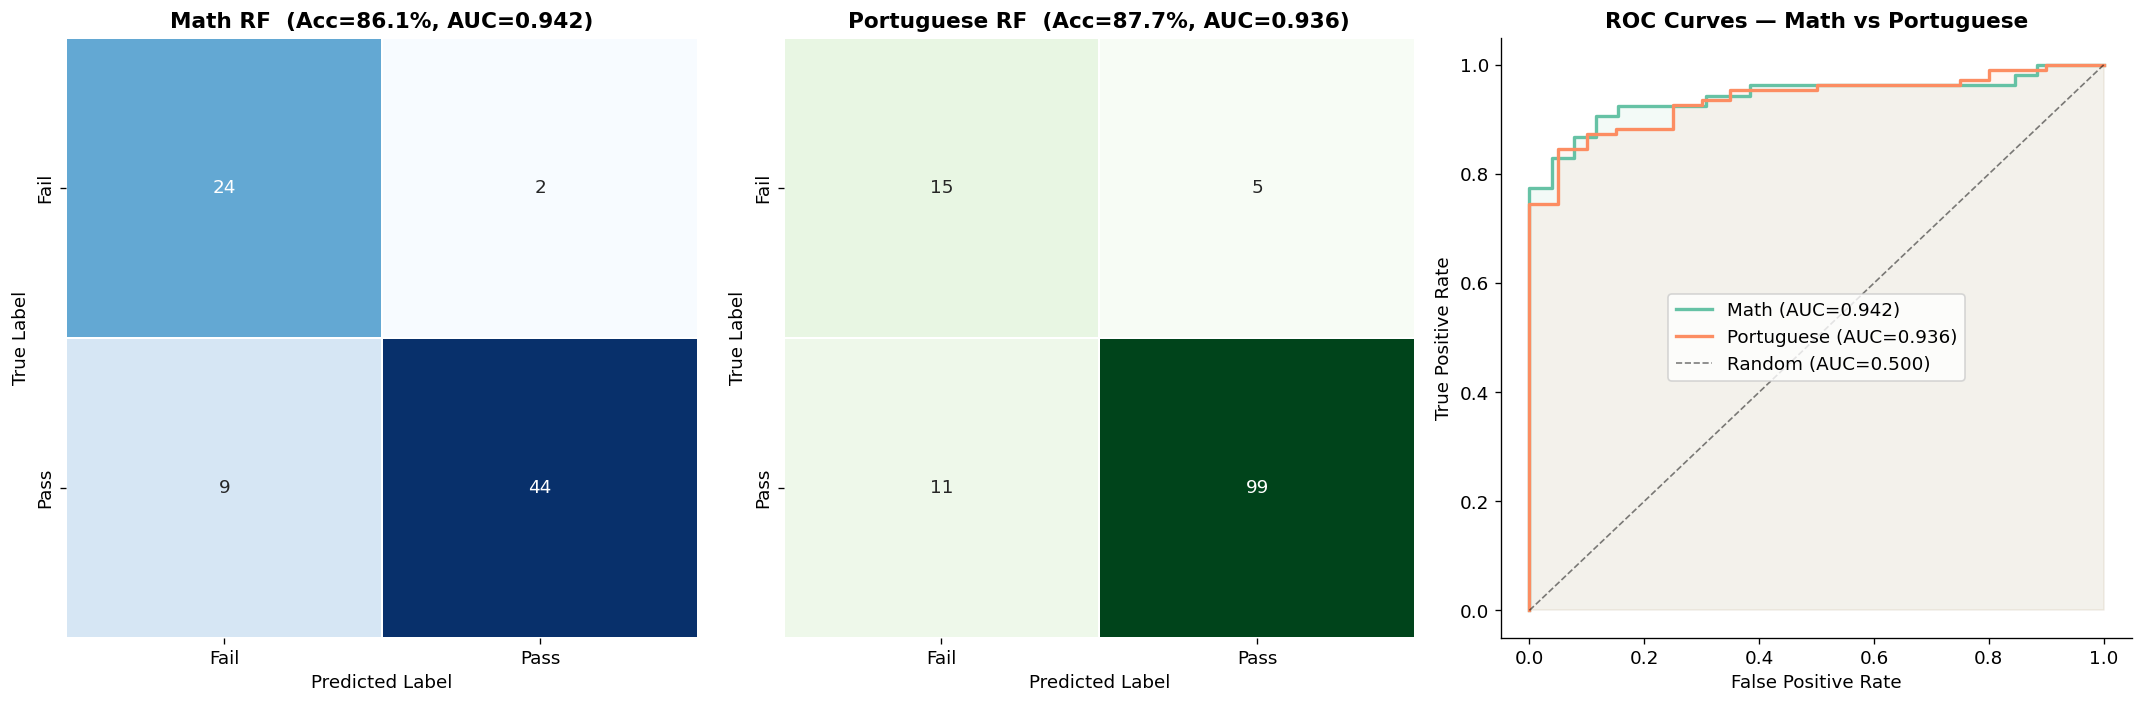

Figure 6 saved -> figures/fig6_rf_comparison.png


In [15]:

# MODEL COMPARISON: MATH vs PORTUGUESE  (Figure 6)

# Three subplots for direct side-by-side comparison.
#
# SUBPLOTS 1 & 2 — Confusion Matrices
#   A 2x2 grid showing prediction outcomes:
#     True Negatives  (predicted Fail,  actually Fail)  <- top-left
#     False Positives (predicted Pass,  actually Fail)  <- top-right  RISKY
#     False Negatives (predicted Fail,  actually Pass)  <- bottom-left
#     True Positives  (predicted Pass,  actually Pass)  <- bottom-right
#   For early-warning systems: False Positives are the costly errors
#   (flagging someone who would have passed), but False Negatives miss
#   real at-risk students — both matter.
#
# SUBPLOT 3 — Overlapping ROC Curves
#   ROC curve plots True Positive Rate vs False Positive Rate at every
#   possible classification threshold.
#   AUC = 1.0  ->  perfect classifier
#   AUC = 0.5  ->  no better than random (diagonal line)
#   Both subjects on the same axes = direct comparison of predictability.


print("Generating Figure 6: Model Comparison (Math vs Portuguese)...")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Confusion matrices for both models
for ax, y_true, y_pred, title, cmap in [
    (axes[0], y_te,  y_pred_m, f'Math RF  (Acc={acc_m*100:.1f}%, AUC={auc_m:.3f})',       'Blues'),
    (axes[1], y_te2, y_pred_p, f'Portuguese RF  (Acc={acc_p*100:.1f}%, AUC={auc_p:.3f})', 'Greens'),
]:
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['Fail','Pass'], yticklabels=['Fail','Pass'],
                cbar=False, linewidths=1)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

# Overlapping ROC curves — same axes for direct comparison
fpr_m, tpr_m, _ = roc_curve(y_te,  y_prob_m)
fpr_p, tpr_p, _ = roc_curve(y_te2, y_prob_p)
axes[2].plot(fpr_m, tpr_m, color=SUBJECT_COLORS['Math'],       lw=2, label=f'Math (AUC={auc_m:.3f})')
axes[2].plot(fpr_p, tpr_p, color=SUBJECT_COLORS['Portuguese'], lw=2, label=f'Portuguese (AUC={auc_p:.3f})')
axes[2].plot([0,1],[0,1], 'k--', lw=1, alpha=0.5, label='Random (AUC=0.500)')
axes[2].fill_between(fpr_m, tpr_m, alpha=0.08, color=SUBJECT_COLORS['Math'])
axes[2].fill_between(fpr_p, tpr_p, alpha=0.08, color=SUBJECT_COLORS['Portuguese'])
axes[2].set_title('ROC Curves — Math vs Portuguese', fontweight='bold')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].legend()

plt.tight_layout()
plt.savefig('figures/fig6_rf_comparison.png', bbox_inches='tight')
plt.show()
print("Figure 6 saved -> figures/fig6_rf_comparison.png")

### 6.4 Feature Importance Comparison: What Predicts Each Subject?

Generating Figure 7: Feature Importance Comparison (Math vs Portuguese)...


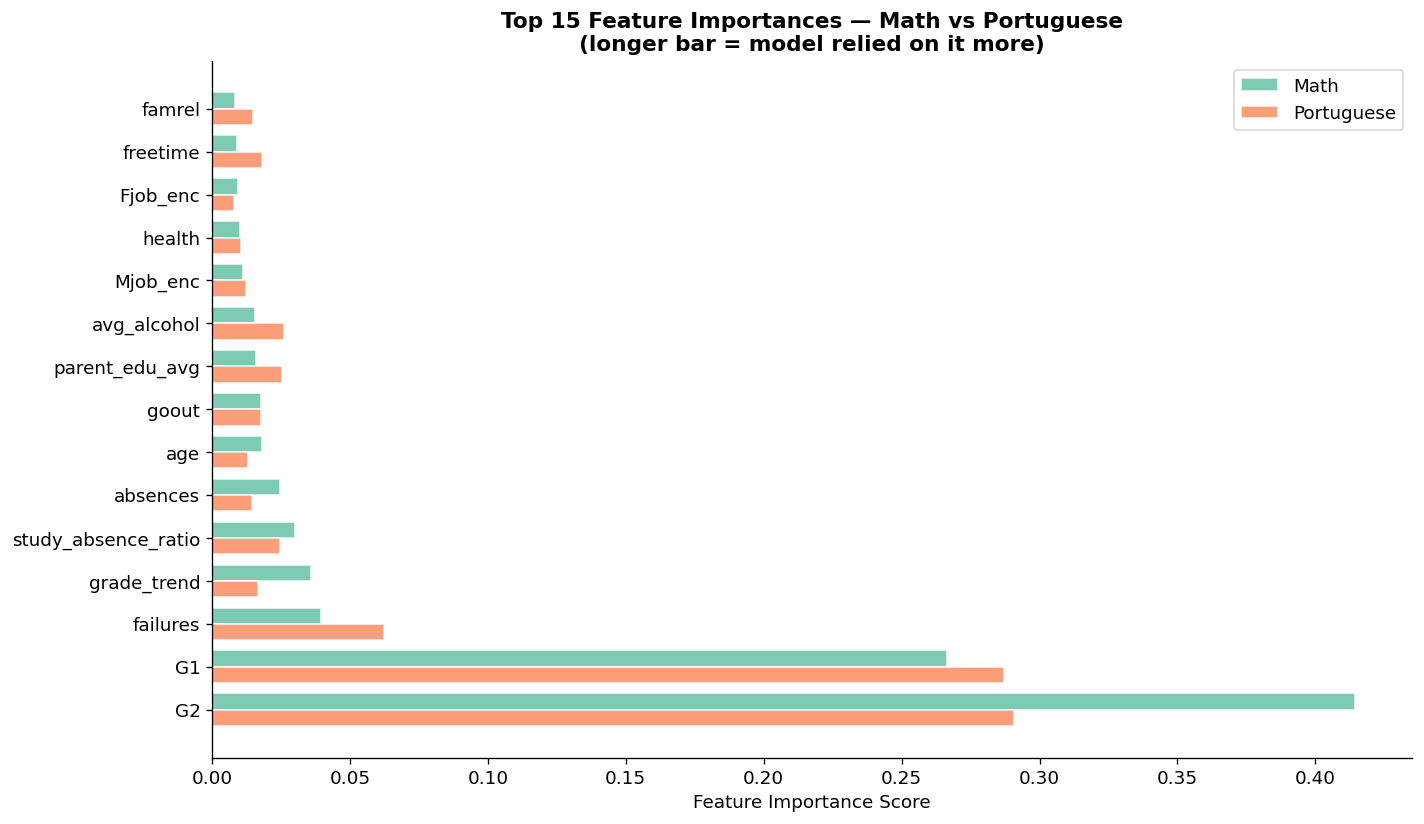


── Top 5 Most Important Features ───────────────────────────────
  Math: G2(0.414), G1(0.267), failures(0.040), grade_trend(0.036), study_absence_ratio(0.030)
  Portuguese: G2(0.291), G1(0.287), failures(0.062), school_enc(0.056), higher_enc(0.032)
Figure 7 saved -> figures/fig7_feature_importance_comparison.png


In [16]:

# FEATURE IMPORTANCE COMPARISON  (Figure 7)

# Random Forests measure feature importance as the average decrease in
# Gini impurity across all trees when splitting on that feature.
# Higher value = the model relied on that feature more when making decisions.
#
# This grouped horizontal bar chart shows the TOP 15 Math features
# alongside the corresponding importance for Portuguese.
#
# KEY QUESTIONS THIS ANSWERS:
#   - Do G2 and G1 dominate both subjects? (Expected: yes — prior grades
#     are the strongest predictor of future performance in both)
#   - Does study time matter more for one subject than the other?
#   - Do the engineered features (grade_trend, avg_alcohol) add value?
#   - Which social factors (alcohol, going out, family support) appear
#     differently across subjects?
#
# If bars look very similar for both subjects:
#   -> Performance is driven by the same underlying factors universally
# If bars diverge significantly:
#   -> Subject-specific interventions may be more effective than general ones


print("Generating Figure 7: Feature Importance Comparison (Math vs Portuguese)...")

fi_mat = pd.Series(dict(zip(feat_cols_mat, rf_math.feature_importances_)))
fi_por = pd.Series(dict(zip(feat_cols_por, rf_port.feature_importances_)))
fi_df  = pd.DataFrame({'Math': fi_mat, 'Portuguese': fi_por}).fillna(0)
fi_df  = fi_df.sort_values('Math', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 7))
x = np.arange(len(fi_df))
w = 0.38
ax.barh(x + w/2, fi_df['Math'],       w, label='Math',       color=SUBJECT_COLORS['Math'],       alpha=0.85, edgecolor='white')
ax.barh(x - w/2, fi_df['Portuguese'], w, label='Portuguese', color=SUBJECT_COLORS['Portuguese'], alpha=0.85, edgecolor='white')
ax.set_yticks(x)
ax.set_yticklabels(fi_df.index)
ax.set_title('Top 15 Feature Importances — Math vs Portuguese\n(longer bar = model relied on it more)', fontweight='bold')
ax.set_xlabel('Feature Importance Score')
ax.legend()
plt.tight_layout()
plt.savefig('figures/fig7_feature_importance_comparison.png', bbox_inches='tight')
plt.show()

print("\n── Top 5 Most Important Features ───────────────────────────────")
for subj, fi in [('Math', fi_mat),('Portuguese', fi_por)]:
    top5 = fi.sort_values(ascending=False).head(5)
    names = ', '.join([f'{n}({v:.3f})' for n, v in top5.items()])
    print(f"  {subj}: {names}")
print("Figure 7 saved -> figures/fig7_feature_importance_comparison.png")

### 6.5 Model 3 — Gradient Boosting: xAPI Three-Class Classification

MODEL 3: Gradient Boosting — xAPI Low / Medium / High
  Features: ['gender_enc', 'Semester_enc', 'Relation_enc', 'ParentAnsweringSurvey_enc', 'ParentschoolSatisfaction_enc', 'StudentAbsenceDays_enc', 'raisedhands', 'VisITedResources', 'AnnouncementsView', 'Discussion', 'engagement_score']
  Class distribution: Low=125, Med=211, High=142



── Results ──────────────────────────────────────────────────
  Test Accuracy        : 76.04%
  AUC-ROC (macro OvR)  : 0.9202
  5-Fold CV            : 73.85% +/- 6.29%

── Classification Report ────────────────────────────────────
              precision    recall  f1-score   support

         Low       0.85      0.88      0.86        25
      Medium       0.71      0.76      0.74        42
        High       0.76      0.66      0.70        29

    accuracy                           0.76        96
   macro avg       0.77      0.77      0.77        96
weighted avg       0.76      0.76      0.76        96

Generating Figure 8: GB Confusion Matrix + Feature Importances...


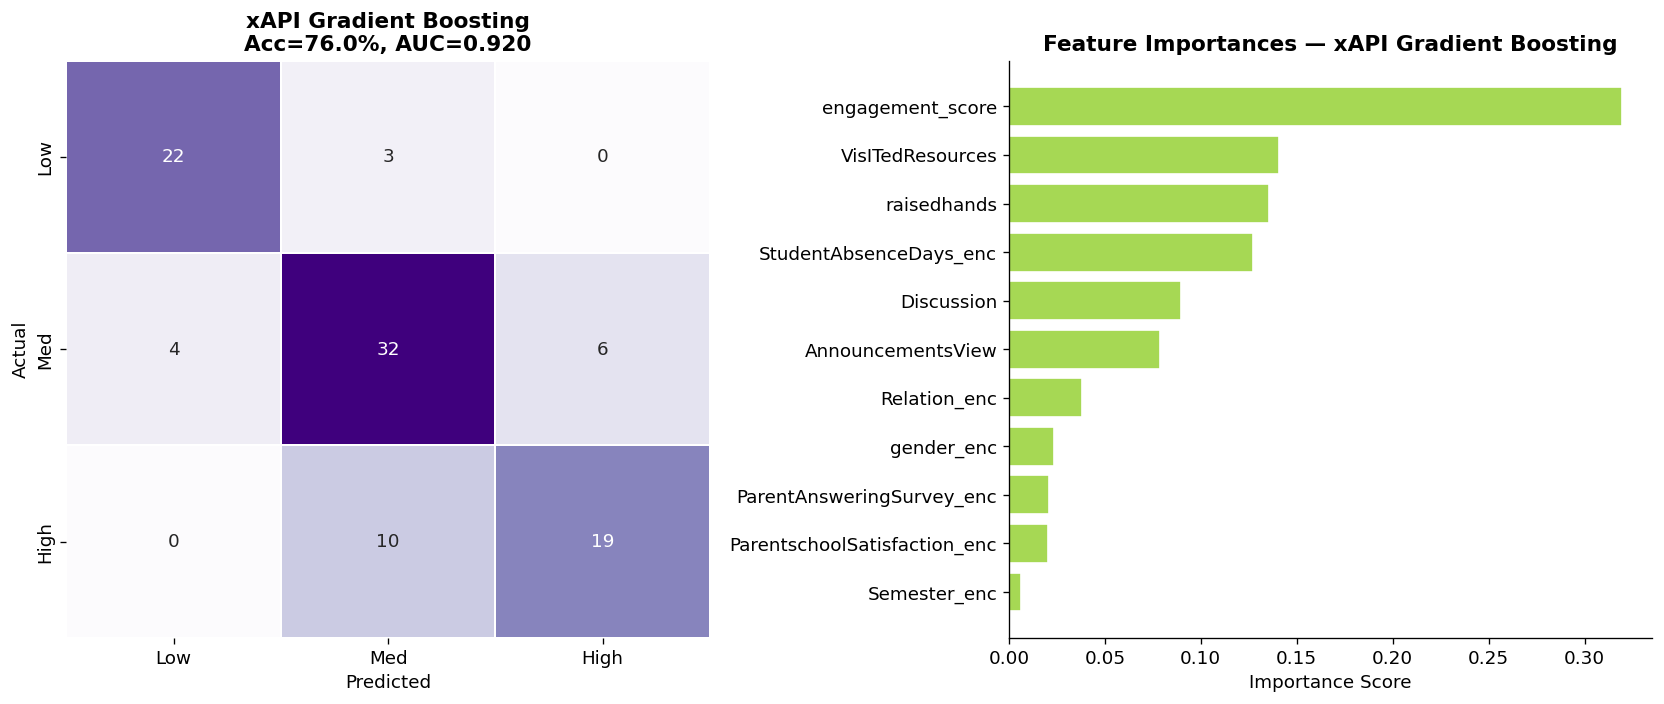

Figure 8 saved -> figures/fig8_gb_xapi.png


In [17]:

# MODEL 3: GRADIENT BOOSTING — xAPI THREE-CLASS

# WHAT IS GRADIENT BOOSTING?
#   Builds decision trees SEQUENTIALLY. Each new tree tries to correct
#   the errors (residuals) of all previous trees combined.
#   More accurate than Random Forest on many structured datasets, but
#   slower to train and more sensitive to hyperparameters.
#
# WHY GRADIENT BOOSTING FOR xAPI (instead of Random Forest)?
#   1. THREE classes (Low/Medium/High) — Random Forest also handles this,
#      but Gradient Boosting tends to perform better on imbalanced multi-class.
#   2. All features are continuous behavioral counts — GB excels here.
#   3. The sequential correction process captures subtle behavioral thresholds.
#
# HYPERPARAMETERS EXPLAINED:
#   n_estimators=200   : 200 sequential trees built
#   learning_rate=0.08 : how much each tree corrects — lower = more stable
#   max_depth=4        : shallow trees prevent overfitting to training noise
#   subsample=0.8      : each tree sees only 80% of data (adds robustness)
#
# THREE-CLASS AUC-ROC:
#   With 3 classes we use One-vs-Rest (OvR): for each class, we ask
#   "how well does the model distinguish THIS class from all others?"
#   Then macro-average (equal weight to each class) for one number.
#   This is a stricter metric than binary AUC.


print("=" * 60)
print("MODEL 3: Gradient Boosting — xAPI Low / Medium / High")
print("=" * 60)

xapi_feats = ([c+'_enc' for c in binary_cols if c+'_enc' in df_x.columns] +
              BEHAV_COLS + ['engagement_score'])
xapi_feats = [f for f in xapi_feats if f in df_x.columns]

X_xapi = df_x[xapi_feats]
y_xapi = df_x['Class_enc']

print(f"  Features: {xapi_feats}")
print(f"  Class distribution: Low={( y_xapi==0).sum()}, Med={(y_xapi==1).sum()}, High={(y_xapi==2).sum()}")

X_tr3, X_te3, y_tr3, y_te3 = train_test_split(X_xapi, y_xapi, test_size=0.2,
                                                random_state=42, stratify=y_xapi)
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.08,
                                 max_depth=4, subsample=0.8, random_state=42)
gb.fit(X_tr3, y_tr3)

y_pred_gb = gb.predict(X_te3)
y_prob_gb = gb.predict_proba(X_te3)
acc_gb = accuracy_score(y_te3, y_pred_gb)
y_bin  = label_binarize(y_te3, classes=[0,1,2])
auc_gb = roc_auc_score(y_bin, y_prob_gb, multi_class='ovr', average='macro')
cv_gb  = cross_val_score(gb, X_xapi, y_xapi,
                          cv=StratifiedKFold(5, shuffle=True, random_state=42),
                          scoring='accuracy')

print(f"\n── Results ──────────────────────────────────────────────────")
print(f"  Test Accuracy        : {acc_gb*100:.2f}%")
print(f"  AUC-ROC (macro OvR)  : {auc_gb:.4f}")
print(f"  5-Fold CV            : {cv_gb.mean()*100:.2f}% +/- {cv_gb.std()*100:.2f}%")
print(f"\n── Classification Report ────────────────────────────────────")
print(classification_report(y_te3, y_pred_gb, target_names=['Low','Medium','High']))

print("Generating Figure 8: GB Confusion Matrix + Feature Importances...")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
cm_gb = confusion_matrix(y_te3, y_pred_gb)
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Purples', ax=axes[0],
            xticklabels=['Low','Med','High'], yticklabels=['Low','Med','High'],
            cbar=False, linewidths=1)
axes[0].set_title(f'xAPI Gradient Boosting\nAcc={acc_gb*100:.1f}%, AUC={auc_gb:.3f}', fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

gb_fi = pd.DataFrame({'feature':xapi_feats,'importance':gb.feature_importances_}).sort_values('importance',ascending=True)
axes[1].barh(gb_fi['feature'], gb_fi['importance'], color=PALETTE[4], edgecolor='white')
axes[1].set_title('Feature Importances — xAPI Gradient Boosting', fontweight='bold')
axes[1].set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('figures/fig8_gb_xapi.png', bbox_inches='tight')
plt.show()
print("Figure 8 saved -> figures/fig8_gb_xapi.png")

### 6.6 All Models — Performance Summary

Generating Figure 9: All Models Performance Summary...


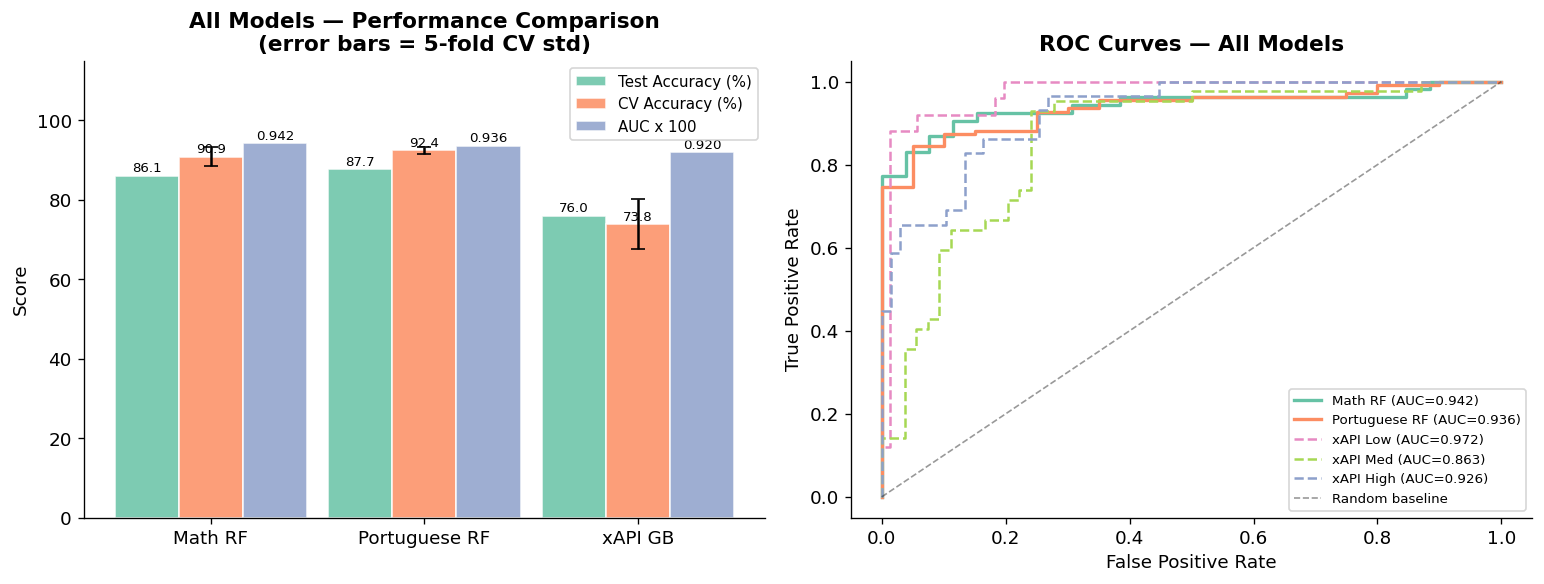

Figure 9 saved -> figures/fig9_all_models_summary.png


In [18]:

# ALL MODELS PERFORMANCE SUMMARY  (Figure 9)

# This figure brings all three models together on two subplots —
# the executive summary of the entire modeling section.
#
# SUBPLOT 1 — Grouped Bar Chart
#   Three metrics shown per model:
#     Blue  : Test Accuracy (%)       <- performance on held-out test set
#     Orange: CV Accuracy  (%)        <- average across 5 cross-validation folds
#     Green : AUC x 100               <- AUC scaled to % for easy comparison
#   Error bars on CV accuracy show the standard deviation across folds.
#   Small error bars = stable model.  Large error bars = sensitive to data split.
#
# SUBPLOT 2 — Unified ROC Curves
#   All 5 ROC curves on one plot:
#     Solid lines  : Math RF and Portuguese RF (binary classification)
#     Dashed lines : xAPI Low, Medium, High classes (one-vs-rest)
#   The diagonal dashed line = random guessing (AUC=0.5).
#   Every curve above this line means the model is better than chance.


print("Generating Figure 9: All Models Performance Summary...")

models  = ['Math RF', 'Portuguese RF', 'xAPI GB']
accs    = [acc_m*100,        acc_p*100,        acc_gb*100]
aucs    = [auc_m,            auc_p,            auc_gb]
cv_mean = [cv_m.mean()*100,  cv_p.mean()*100,  cv_gb.mean()*100]
cv_std  = [cv_m.std()*100,   cv_p.std()*100,   cv_gb.std()*100]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x = np.arange(len(models))
w = 0.3

axes[0].bar(x - w, accs,              w, label='Test Accuracy (%)', color=PALETTE[0], alpha=0.85, edgecolor='white')
axes[0].bar(x,     cv_mean,           w, label='CV Accuracy (%)',   color=PALETTE[1], alpha=0.85, edgecolor='white')
axes[0].errorbar(x, cv_mean, yerr=cv_std, fmt='none', color='black', capsize=4)
axes[0].bar(x + w, [a*100 for a in aucs], w, label='AUC x 100',    color=PALETTE[2], alpha=0.85, edgecolor='white')
axes[0].set_xticks(x); axes[0].set_xticklabels(models)
axes[0].set_ylabel('Score'); axes[0].set_ylim(0, 115)
axes[0].set_title('All Models — Performance Comparison\n(error bars = 5-fold CV std)', fontweight='bold')
axes[0].legend(fontsize=9)
for i, (a, cv, auc) in enumerate(zip(accs, cv_mean, aucs)):
    axes[0].text(i-w, a+1, f'{a:.1f}', ha='center', fontsize=8)
    axes[0].text(i,   cv+1, f'{cv:.1f}', ha='center', fontsize=8)
    axes[0].text(i+w, auc*100+1, f'{auc:.3f}', ha='center', fontsize=8)

fpr_m, tpr_m, _ = roc_curve(y_te,  y_prob_m)
fpr_p, tpr_p, _ = roc_curve(y_te2, y_prob_p)
axes[1].plot(fpr_m, tpr_m, color=SUBJECT_COLORS['Math'],       lw=2, label=f'Math RF (AUC={auc_m:.3f})')
axes[1].plot(fpr_p, tpr_p, color=SUBJECT_COLORS['Portuguese'], lw=2, label=f'Portuguese RF (AUC={auc_p:.3f})')
for i, (cls, col) in enumerate(zip(['Low','Med','High'],[PALETTE[3],PALETTE[4],PALETTE[2]])):
    fpr_i, tpr_i, _ = roc_curve(y_bin[:,i], y_prob_gb[:,i])
    auc_i = roc_auc_score(y_bin[:,i], y_prob_gb[:,i])
    axes[1].plot(fpr_i, tpr_i, color=col, lw=1.5, linestyle='--', label=f'xAPI {cls} (AUC={auc_i:.3f})')
axes[1].plot([0,1],[0,1], 'k--', lw=1, alpha=0.4, label='Random baseline')
axes[1].set_title('ROC Curves — All Models', fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig('figures/fig9_all_models_summary.png', bbox_inches='tight')
plt.show()
print("Figure 9 saved -> figures/fig9_all_models_summary.png")

### 6.7 Baselines — Is Random Forest Actually Adding Value?

An accuracy of 86–88% sounds strong, but a number on its own means little without something to compare it to. Before trusting the Random Forest models, we check them against three simpler baselines on **exactly the same train/test split**:

1. **Majority class** — always predict *Pass*. This is the accuracy you get for free, just from the class imbalance.
2. **Simple rule: G2 ≥ 10** — predict *Pass* if the second-period grade is already a pass. No machine learning at all.
3. **Logistic Regression** — a linear model on the same features as the Random Forest.

We also report **recall for the Fail class**: the share of students who actually failed that the model catches. For an early-warning system this matters more than overall accuracy, because missing an at-risk student is the costly mistake.

> **What to look for:** if a one-line rule on G2 performs about as well as the Random Forest, the high accuracy comes mostly from the interim grades, not from the model.

In [19]:
# BASELINES — IS RANDOM FOREST ACTUALLY ADDING VALUE?

# A model's accuracy only means something next to a baseline.
# All models below use the SAME 80/20 split as Models 1 and 2
# (random_state=42, stratified), so the numbers are directly comparable.
#
# BASELINES:
#   Majority class : DummyClassifier — always predicts the most common class (Pass)
#   Rule G2 >= 10  : pass if the second-period grade is already a pass
#                    (AUC uses the raw G2 value as the score)
#   Logistic Reg.  : linear model, features standardised, balanced class weights
#   Random Forest  : same hyperparameters as Models 1 and 2
#
# METRICS:
#   Accuracy, AUC-ROC, 5-fold CV accuracy (same folds as before), and
#   FAIL RECALL = of the students who actually failed, how many did we flag?

from sklearn.dummy import DummyClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import recall_score

CV5 = StratifiedKFold(5, shuffle=True, random_state=42)

def make_rf():
    return RandomForestClassifier(n_estimators=300, max_depth=10,
                                  min_samples_leaf=3, class_weight='balanced',
                                  random_state=42, n_jobs=-1)

def make_lr():
    return make_pipeline(StandardScaler(),
                         LogisticRegression(max_iter=2000, class_weight='balanced'))

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te, X_all, y_all):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    prob = model.predict_proba(X_te)[:, 1]
    cv   = cross_val_score(model, X_all, y_all, cv=CV5, scoring='accuracy')
    auc  = roc_auc_score(y_te, prob) if len(np.unique(prob)) > 1 else 0.5
    return {'Model': name,
            'Accuracy': accuracy_score(y_te, pred) * 100,
            'AUC': auc,
            'Fail recall': recall_score(y_te, pred, pos_label=0) * 100,
            'CV mean': cv.mean() * 100,
            'CV std': cv.std() * 100}

def evaluate_g2_rule(X_te, y_te, X_all, y_all):
    # No training needed — the rule is fixed, so CV just applies it to each fold
    pred = (X_te['G2'] >= 10).astype(int)
    cv = [accuracy_score(y_all.iloc[te], (X_all['G2'].iloc[te] >= 10).astype(int))
          for _, te in CV5.split(X_all, y_all)]
    return {'Model': 'Rule: G2 >= 10',
            'Accuracy': accuracy_score(y_te, pred) * 100,
            'AUC': roc_auc_score(y_te, X_te['G2']),
            'Fail recall': recall_score(y_te, pred, pos_label=0) * 100,
            'CV mean': np.mean(cv) * 100,
            'CV std': np.std(cv) * 100}

def print_results(df):
    print(f"  {'Model':<24} {'Accuracy':>9} {'AUC':>7} {'Fail recall':>12} {'5-Fold CV':>18}")
    print(f"  {'─'*74}")
    for _, r in df.iterrows():
        print(f"  {r['Model']:<24} {r['Accuracy']:>8.2f}% {r['AUC']:>7.3f} {r['Fail recall']:>11.1f}% "
              f"{r['CV mean']:>9.2f}% +/- {r['CV std']:.2f}%")

SUBJECTS = [('Math', X_mat, y_mat), ('Portuguese', X_por, y_por)]
baseline_results = {}

print("=" * 78)
print("BASELINE COMPARISON — ALL FEATURES (including G1, G2)")
print("=" * 78)

for subj, X, y in SUBJECTS:
    X_tr_b, X_te_b, y_tr_b, y_te_b = train_test_split(X, y, test_size=0.2,
                                                      random_state=42, stratify=y)
    rows = [
        evaluate_model('Majority class', DummyClassifier(strategy='most_frequent'),
                       X_tr_b, X_te_b, y_tr_b, y_te_b, X, y),
        evaluate_g2_rule(X_te_b, y_te_b, X, y),
        evaluate_model('Logistic Regression', make_lr(), X_tr_b, X_te_b, y_tr_b, y_te_b, X, y),
        evaluate_model('Random Forest', make_rf(), X_tr_b, X_te_b, y_tr_b, y_te_b, X, y),
    ]
    baseline_results[subj] = pd.DataFrame(rows)
    print(f"\n── {subj} {'─'*(70-len(subj))}")
    print_results(baseline_results[subj])

print("\n── Takeaway ─────────────────────────────────────────────────────────────")
for subj in baseline_results:
    df_b = baseline_results[subj].set_index('Model')
    gain = df_b.loc['Random Forest', 'Accuracy'] - df_b.loc['Rule: G2 >= 10', 'Accuracy']
    print(f"  {subj:<11}: Random Forest vs the G2 rule = {gain:+.2f} accuracy points")

BASELINE COMPARISON — ALL FEATURES (including G1, G2)



── Math ──────────────────────────────────────────────────────────────────
  Model                     Accuracy     AUC  Fail recall          5-Fold CV
  ──────────────────────────────────────────────────────────────────────────
  Majority class              67.09%   0.500         0.0%     67.09% +/- 0.00%
  Rule: G2 >= 10              87.34%   0.958        96.2%     91.90% +/- 2.06%
  Logistic Regression         86.08%   0.945        92.3%     91.14% +/- 2.26%
  Random Forest               86.08%   0.942        92.3%     90.89% +/- 2.45%



── Portuguese ────────────────────────────────────────────────────────────
  Model                     Accuracy     AUC  Fail recall          5-Fold CV
  ──────────────────────────────────────────────────────────────────────────
  Majority class              84.62%   0.500         0.0%     84.59% +/- 0.05%
  Rule: G2 >= 10              90.77%   0.976        95.0%     89.68% +/- 1.35%
  Logistic Regression         86.92%   0.938        75.0%     89.68% +/- 0.77%
  Random Forest               87.69%   0.936        75.0%     92.45% +/- 0.90%

── Takeaway ─────────────────────────────────────────────────────────────
  Math       : Random Forest vs the G2 rule = -1.27 accuracy points
  Portuguese : Random Forest vs the G2 rule = -3.08 accuracy points


**Result.** Neither Logistic Regression nor Random Forest beats the one-line rule *G2 ≥ 10*. The rule is more accurate (Math 87.3% vs 86.1%; Portuguese 90.8% vs 87.7%) and catches more of the failing students (96% and 95% fail recall).

This is because G2 is almost the answer already: it correlates at r = 0.90 with the final grade in Math (Section 5.4). The 86–88% accuracies in Sections 6.1–6.2 are real, but they mostly reflect the interim grades rather than anything the models learn beyond them. With G2 available, a simple rule is the better choice: it is as accurate, and every teacher can understand it.

### 6.8 Early-Warning Models — Predicting Without Interim Grades

The baselines show that most of the predictive power comes from G1 and G2. That is useful mid-year, but by the time G2 is known a large part of the course is over. The more valuable question for a school is:

> *Can we flag at-risk students at the **start** of the year, before any grades exist?*

Here we retrain Random Forest and Logistic Regression **without G1, G2 and `grade_trend`** (which is derived from them). The models can only use information available on day one: demographics, family background, study habits, past failures, absences and social factors.

We expect accuracy to drop. The goal is to measure *how much* predictive signal remains without grades, which is the honest measure of an early-warning system.

EARLY-WARNING MODELS — NO G1 / G2 / grade_trend



── Math  (28 features) ────────────────────────────────────────────────
  Model                     Accuracy     AUC  Fail recall          5-Fold CV
  ──────────────────────────────────────────────────────────────────────────
  Majority class              67.09%   0.500         0.0%     67.09% +/- 0.00%
  Logistic Regression         70.89%   0.604        50.0%     67.85% +/- 5.69%
  Random Forest               68.35%   0.627        38.5%     72.66% +/- 2.61%
  Random Forest (G1 only)     79.75%   0.869        80.8%     83.54% +/- 1.79%



── Portuguese  (28 features) ──────────────────────────────────────────
  Model                     Accuracy     AUC  Fail recall          5-Fold CV
  ──────────────────────────────────────────────────────────────────────────
  Majority class              84.62%   0.500         0.0%     84.59% +/- 0.05%
  Logistic Regression         70.00%   0.676        55.0%     76.27% +/- 2.19%
  Random Forest               78.46%   0.662        30.0%     85.52% +/- 2.12%
  Random Forest (G1 only)     85.38%   0.831        65.0%     90.60% +/- 1.91%

── Cost of Predicting Early (Random Forest) ──────────────────────────────
  Math       : AUC  all features 0.942  ->  G1 only 0.869  ->  no grades 0.627
               fail recall      92.3%  ->  G1 only 80.8%  ->  no grades 38.5%
  Portuguese : AUC  all features 0.936  ->  G1 only 0.831  ->  no grades 0.662
               fail recall      75.0%  ->  G1 only 65.0%  ->  no grades 30.0%

Generating Figure 14: Baselines vs Early-Warning Models...


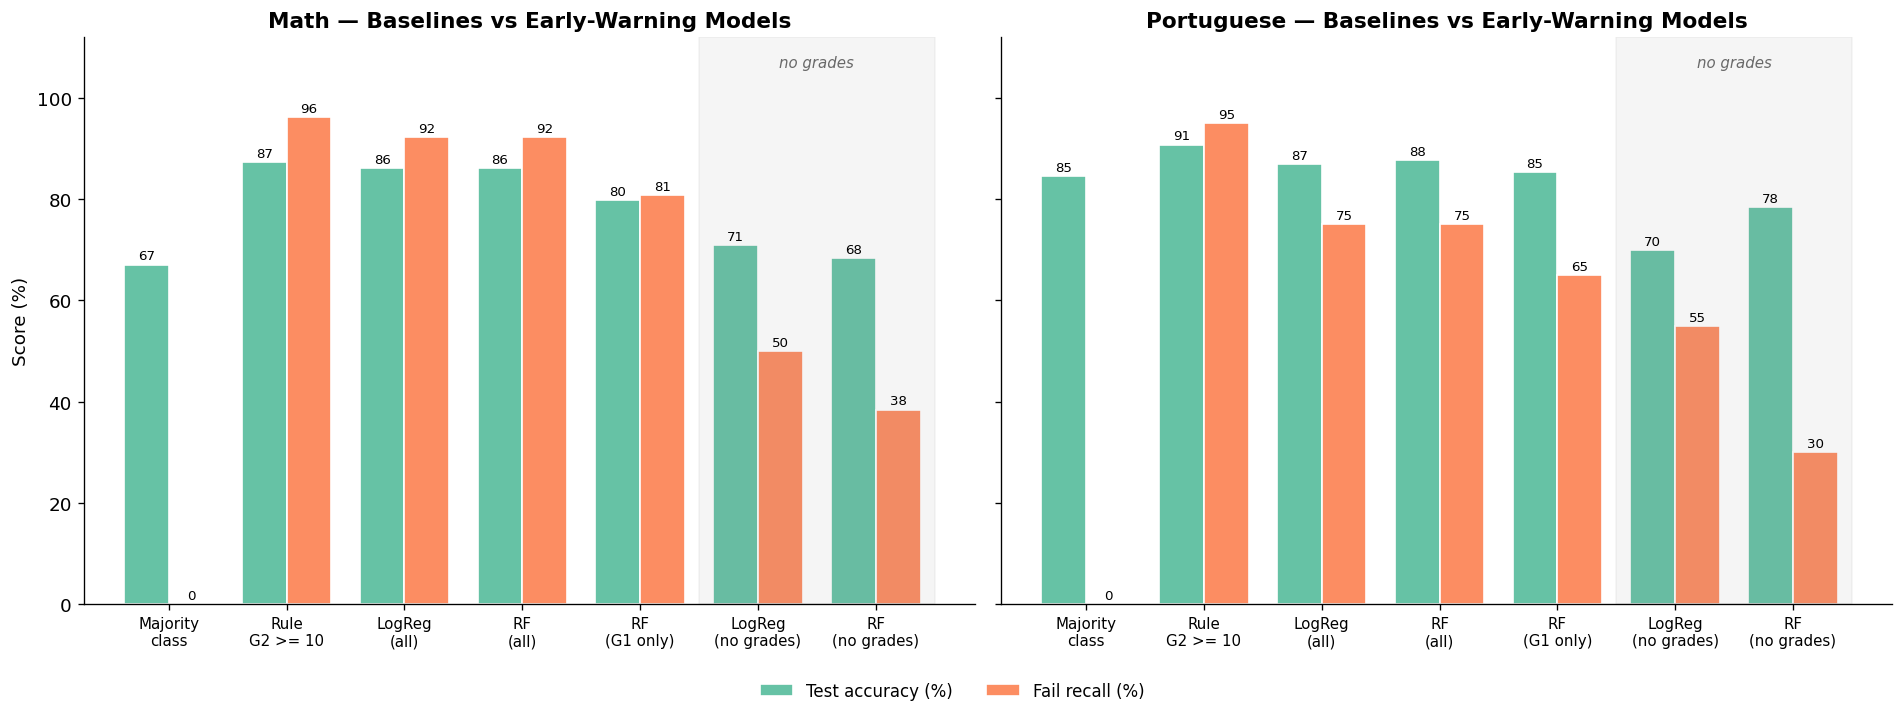

Figure 14 saved -> figures/fig14_baselines_early_warning.png


In [20]:
# EARLY-WARNING MODELS — NO INTERIM GRADES

# Remove every feature that depends on grades from the current year:
#   G1, G2       : first- and second-period grades
#   grade_trend  : G2 - G1, so it leaks the same information
#
# 'failures' (past course failures) is KEPT — it describes previous years
# and is known before the current course starts.
#
# MIDDLE GROUND — 'RF (G1 only)':
#   Keeps G1 but drops G2 and grade_trend. This is the model a school could
#   run after the FIRST grading period, roughly a third of the way into the
#   year — still early enough to intervene.
#
# Same split, same folds, same hyperparameters as before, so any change
# in performance comes only from removing the grade features.

GRADE_FEATURES = ['G1', 'G2', 'grade_trend']
early_results = {}
early_models  = {}   # fitted early-warning Random Forests, reused for SHAP in 6.9

print("=" * 78)
print("EARLY-WARNING MODELS — NO G1 / G2 / grade_trend")
print("=" * 78)

for subj, X, y in SUBJECTS:
    X_early = X.drop(columns=GRADE_FEATURES)
    X_tr_e, X_te_e, y_tr_e, y_te_e = train_test_split(X_early, y, test_size=0.2,
                                                      random_state=42, stratify=y)
    rf_early = make_rf()
    rows = [
        evaluate_model('Majority class', DummyClassifier(strategy='most_frequent'),
                       X_tr_e, X_te_e, y_tr_e, y_te_e, X_early, y),
        evaluate_model('Logistic Regression', make_lr(), X_tr_e, X_te_e, y_tr_e, y_te_e, X_early, y),
        evaluate_model('Random Forest', rf_early, X_tr_e, X_te_e, y_tr_e, y_te_e, X_early, y),
    ]
    # Middle ground: first-period grade only
    X_g1 = X.drop(columns=['G2', 'grade_trend'])
    X_tr_g, X_te_g, y_tr_g, y_te_g = train_test_split(X_g1, y, test_size=0.2,
                                                      random_state=42, stratify=y)
    rows.append(evaluate_model('Random Forest (G1 only)', make_rf(),
                               X_tr_g, X_te_g, y_tr_g, y_te_g, X_g1, y))
    early_results[subj] = pd.DataFrame(rows)
    early_models[subj]  = (rf_early, X_te_e, y_te_e)
    print(f"\n── {subj}  ({X_early.shape[1]} features) {'─'*(52-len(subj))}")
    print_results(early_results[subj])

print("\n── Cost of Predicting Early (Random Forest) ──────────────────────────────")
for subj in early_results:
    full  = baseline_results[subj].set_index('Model').loc['Random Forest']
    g1    = early_results[subj].set_index('Model').loc['Random Forest (G1 only)']
    early = early_results[subj].set_index('Model').loc['Random Forest']
    print(f"  {subj:<11}: AUC  all features {full['AUC']:.3f}  ->  G1 only {g1['AUC']:.3f}  ->  no grades {early['AUC']:.3f}")
    print(f"  {'':<11}  fail recall      {full['Fail recall']:.1f}%  ->  G1 only {g1['Fail recall']:.1f}%  ->  no grades {early['Fail recall']:.1f}%")

# FIGURE 14 — full-feature models vs early-warning models, per subject
print("\nGenerating Figure 14: Baselines vs Early-Warning Models...")
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
for ax, subj in zip(axes, ['Math', 'Portuguese']):
    b = baseline_results[subj].set_index('Model')
    e = early_results[subj].set_index('Model')
    labels = ['Majority\nclass', 'Rule\nG2 >= 10', 'LogReg\n(all)', 'RF\n(all)',
              'RF\n(G1 only)', 'LogReg\n(no grades)', 'RF\n(no grades)']
    order = [(b, 'Majority class'), (b, 'Rule: G2 >= 10'), (b, 'Logistic Regression'),
             (b, 'Random Forest'), (e, 'Random Forest (G1 only)'),
             (e, 'Logistic Regression'), (e, 'Random Forest')]
    acc = [src.loc[m, 'Accuracy'] for src, m in order]
    rec = [src.loc[m, 'Fail recall'] for src, m in order]
    x = np.arange(len(labels)); w = 0.38
    ax.bar(x - w/2, acc, w, label='Test accuracy (%)', color=PALETTE[0], edgecolor='white')
    ax.bar(x + w/2, rec, w, label='Fail recall (%)',   color=PALETTE[1], edgecolor='white')
    for i, (a, r) in enumerate(zip(acc, rec)):
        ax.text(i - w/2, a + 1, f'{a:.0f}', ha='center', fontsize=8)
        ax.text(i + w/2, r + 1, f'{r:.0f}', ha='center', fontsize=8)
    ax.axvspan(4.5, 6.5, color='grey', alpha=0.08)
    ax.text(5.5, 106, 'no grades', ha='center', fontsize=9, style='italic', color='dimgrey')
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylim(0, 112)
    ax.set_title(f'{subj} — Baselines vs Early-Warning Models', fontweight='bold')
axes[0].set_ylabel('Score (%)')
handles, lbls = axes[0].get_legend_handles_labels()
fig.legend(handles, lbls, loc='lower center', ncol=2, fontsize=10, frameon=False)
plt.tight_layout(rect=(0, 0.06, 1, 1))
plt.savefig('figures/fig14_baselines_early_warning.png', bbox_inches='tight')
plt.show()
print("Figure 14 saved -> figures/fig14_baselines_early_warning.png")

**Result.** Removing the grades changes the picture completely:

- **No grades:** AUC falls from about 0.94 to **0.63 (Math)** and **0.66 (Portuguese)**. For Math, the Random Forest (68.4%) is barely above always predicting *Pass* (67.1%).
- **Accuracy is misleading here.** In Portuguese 85% of students pass, so the early Random Forest reaches 78.5% accuracy while catching only **30%** of the students who fail. Logistic Regression with balanced class weights catches more (50–55%), at the cost of more false alarms.
- **G1 only:** once the first-period grade is available, performance recovers most of the way to the full model (see the *Random Forest (G1 only)* rows).

**What this means in practice:** demographic and social data carry some signal, but not enough for a reliable early-warning system on their own. A school would get more value from (a) acting on the first-period grade as soon as it exists, and (b) collecting behavioural engagement data: the xAPI model in Section 6.5 reaches AUC 0.92 without any grades, although on a different population and a 3-class task.

### 6.9 Explainability — Why Is a Student Flagged? (SHAP)

Feature importance (Section 6.4) tells us which features matter *on average*, but not the **direction** of the effect or **why one particular student** was flagged. For an early-warning system that a teacher acts on, both matter.

**SHAP** (SHapley Additive exPlanations) splits each prediction into contributions from every feature. A positive SHAP value pushes the student *towards failing*, a negative one *towards passing*, and the contributions add up to the model's output.

We explain the **Portuguese early-warning Random Forest** (no grades), the larger of the two datasets and the model that would be used at the start of the year:

- **Figure 15 (beeswarm):** every dot is one student in the test set. Position = impact on fail risk; colour = the feature's value (red = high, blue = low).
- **Figure 16 (waterfall):** a single high-risk student, showing exactly which factors raised or lowered their risk.

── Top 8 Drivers of Fail Risk (mean |SHAP|) ─────────────────────
  failures               0.0975   (higher value -> MORE risk)
  school_enc             0.0957   (higher value -> MORE risk)
  higher_enc             0.0489   (higher value -> LESS risk)
  parent_edu_avg         0.0366   (higher value -> LESS risk)
  avg_alcohol            0.0271   (higher value -> MORE risk)
  study_absence_ratio    0.0233   (higher value -> LESS risk)
  guardian_enc           0.0191   (higher value -> MORE risk)
  address_enc            0.0176   (higher value -> LESS risk)

Generating Figure 15: SHAP Summary (Portuguese early-warning model)...


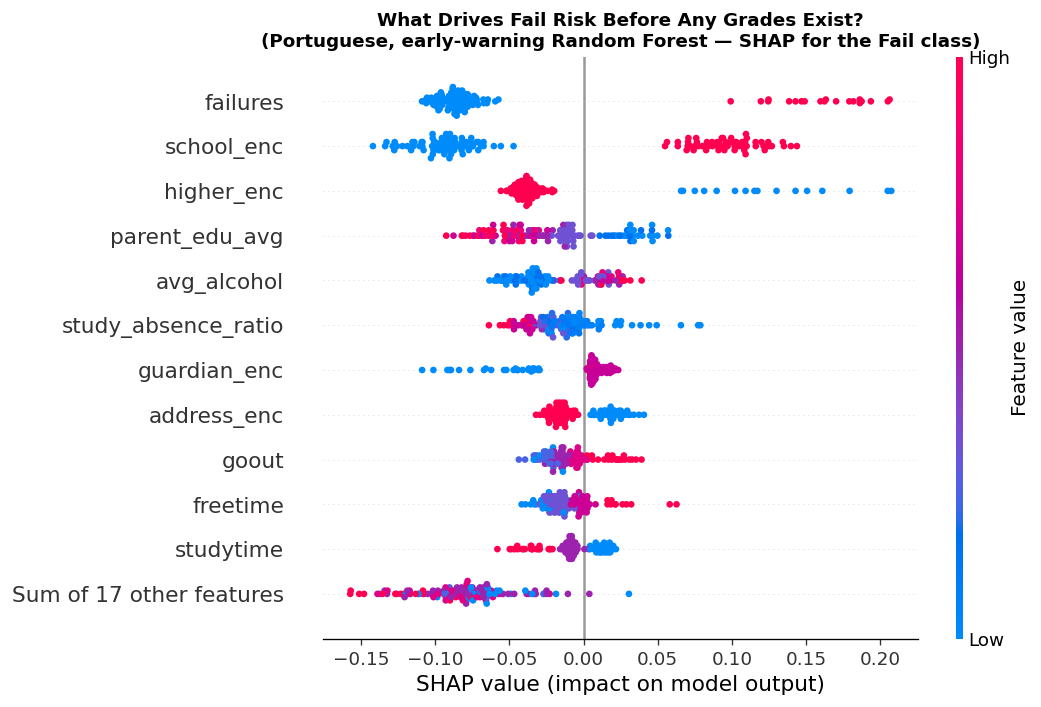

Figure 15 saved -> figures/fig15_shap_summary.png

Highest-risk student overall: fail probability 0.78, actual: Pass
Highest-risk student who actually failed: fail probability 0.76
Generating Figure 16: SHAP Explanation for One Student...


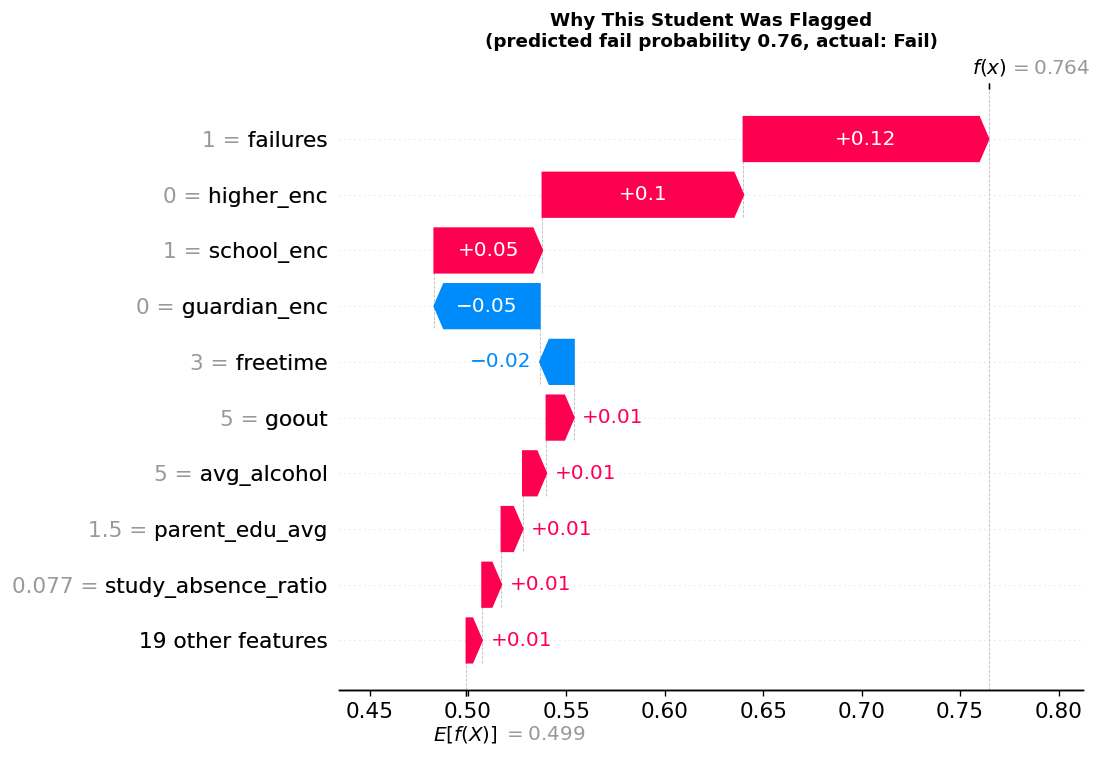

Figure 16 saved -> figures/fig16_shap_single_student.png


In [21]:
# EXPLAINABILITY WITH SHAP — PORTUGUESE EARLY-WARNING MODEL

# TreeExplainer computes exact SHAP values for tree ensembles quickly.
# The model predicts two classes: 0 = Fail, 1 = Pass.
# We explain the FAIL class, so:
#   SHAP > 0  -> this feature pushes the student TOWARDS failing
#   SHAP < 0  -> this feature pushes the student TOWARDS passing
#
# Explaining the test set only (130 students) keeps the explanations honest:
# these are students the model never saw during training.

import shap

rf_early_por, X_te_shap, y_te_shap = early_models['Portuguese']

explainer  = shap.TreeExplainer(rf_early_por)
shap_all   = explainer(X_te_shap)          # shape: (students, features, classes)
shap_fail  = shap_all[:, :, 0]             # class 0 = Fail

# Rank features by average absolute impact on fail risk
mean_abs = pd.Series(np.abs(shap_fail.values).mean(axis=0),
                     index=X_te_shap.columns).sort_values(ascending=False)

# Direction: does a HIGH value of the feature raise or lower fail risk?
direction = {f: np.corrcoef(X_te_shap[f], shap_fail[:, f].values)[0, 1]
             for f in mean_abs.index[:8]}

print("── Top 8 Drivers of Fail Risk (mean |SHAP|) ─────────────────────")
for f in mean_abs.index[:8]:
    arrow = 'higher value -> MORE risk' if direction[f] > 0 else 'higher value -> LESS risk'
    print(f"  {f:<22} {mean_abs[f]:.4f}   ({arrow})")

# FIGURE 15 — beeswarm summary
print("\nGenerating Figure 15: SHAP Summary (Portuguese early-warning model)...")
plt.figure()
shap.plots.beeswarm(shap_fail, max_display=12, show=False)
plt.title('What Drives Fail Risk Before Any Grades Exist?\n(Portuguese, early-warning Random Forest — SHAP for the Fail class)',
          fontweight='bold', fontsize=11)
plt.savefig('figures/fig15_shap_summary.png', bbox_inches='tight')
plt.show()
print("Figure 15 saved -> figures/fig15_shap_summary.png")

# FIGURE 16 — waterfall for one correctly flagged student
#   We pick the student with the highest predicted fail risk among those
#   who ACTUALLY failed, so the example shows a real at-risk case.
#   (The single highest-risk student overall actually passed — a reminder
#   that an early-warning model produces false alarms too.)
fail_prob = rf_early_por.predict_proba(X_te_shap)[:, 0]
top = int(np.argmax(fail_prob))
print(f"\nHighest-risk student overall: fail probability {fail_prob[top]:.2f}, "
      f"actual: {'Fail' if y_te_shap.iloc[top] == 0 else 'Pass'}")

failed = np.where(y_te_shap.values == 0)[0]
idx = int(failed[np.argmax(fail_prob[failed])])
actual = 'Fail'
print(f"Highest-risk student who actually failed: fail probability {fail_prob[idx]:.2f}")

print("Generating Figure 16: SHAP Explanation for One Student...")
plt.figure()
shap.plots.waterfall(shap_fail[idx], max_display=10, show=False)
plt.title(f'Why This Student Was Flagged\n(predicted fail probability {fail_prob[idx]:.2f}, actual: {actual})',
          fontweight='bold', fontsize=11)
plt.savefig('figures/fig16_shap_single_student.png', bbox_inches='tight')
plt.show()
print("Figure 16 saved -> figures/fig16_shap_single_student.png")


**Result.** Before any grades exist, the strongest drivers of fail risk in the Portuguese data are:

- **Past failures:** the single biggest factor. Every previously failed course raises the risk.
- **School:** students at Mousinho da Silveira (`school_enc = 1`) are at noticeably higher risk than those at Gabriel Pereira. This probably reflects differences between the two schools, not the students, so it is a question for the schools to investigate rather than a reason to flag individuals.
- **Plans for higher education** (`higher_enc`): students who want to go to university are at lower risk.
- **Parental education** and a better **study-to-absence ratio** lower risk; higher **alcohol use** raises it.

These are consistent with the association rules for Math in Section 8, where *past failures + high alcohol use → fail* was the strongest rule.

**A note on fairness.** Several of these features (school, guardian, home address, parents' education) describe a student's *background*, not their effort. An early-warning system built on them should be used to **offer extra support**, never to label or track students, and its false alarms (like the highest-risk student in this test set, who actually passed) need to be taken seriously.


## 7. Unsupervised Learning — K-Means Clustering

Unlike supervised learning, clustering has **no labels**. It finds natural groupings in the data purely from the patterns in the features. The question we are asking is: *do students naturally fall into distinct behavioural or academic archetypes, even without being told what those archetypes are?*

**Why K-Means?** It is simple, interpretable, and well-suited to finding compact clusters in continuous feature spaces. We run it on two separate datasets to see if consistent archetypes emerge from both.

**How to choose k (number of clusters):**
- **Elbow curve** — Plot inertia (within-cluster variance) vs k. Look for the 'elbow' where adding more clusters stops giving much benefit.
- **Silhouette score** — Measures how similar each point is to its own cluster vs other clusters. Higher is better (max = 1).

**How to interpret the clusters:**  
After assigning students to clusters, we profile each group by its mean feature values. A cluster with high `engagement_score` and low `high_absence` is an 'Active Learner'. A cluster with the opposite pattern is a 'Passive Learner'. The labels come from the data — not from us.

### 7.1 Clustering on UCI (Math + Portuguese Combined)

In [22]:

# K-MEANS CLUSTERING: UCI COMBINED  (Figures 10)

# WHAT IS K-MEANS?
#   K-Means partitions students into k groups (clusters) so that each
#   student belongs to the cluster with the nearest centre (centroid).
#   It is UNSUPERVISED — it does NOT use the pass/fail label during
#   clustering. Any alignment with actual outcomes is a genuine discovery.
#
# WHY COMBINE MATH AND PORTUGUESE?
#   We pool all students from both datasets (395 + 649 = 1044 rows).
#   More data -> more stable, reliable clusters.
#   Patterns appearing in BOTH subjects are more generalizable.
#
# FEATURES USED:
#   studytime, failures, absences, avg_alcohol, parent_edu_avg, G1, G2, G3
#   Academic performance + social and family context simultaneously.
#   StandardScaler normalises to zero mean and unit variance so that
#   features on larger scales (like absences 0-90) do not dominate
#   features on smaller scales (like studytime 1-4).
#
# CHOOSING k — TWO METHODS:
#   Elbow method : plot inertia for k=2..8.
#     The point where adding more clusters gives diminishing returns
#     is the natural k. We look for the 'bend' in the curve.
#   Silhouette score : measures how well-separated clusters are.
#     Score near +1 = clusters are tight and well-separated.
#     Score near  0 = overlapping clusters.
#   We use k=3 for interpretability: Low / Mid / High Achiever.
#
# CLUSTER LABELLING:
#   After fitting, we rank clusters by their mean G3 grade.
#   Lowest mean G3 -> Low Achiever, highest -> High Achiever.


print("=" * 60)
print("CLUSTERING 1: K-Means on UCI Combined (Math + Portuguese)")
print("=" * 60)

# Pool students from both subjects
uci_all = pd.concat([
    df_mat_p[['studytime','failures','absences','avg_alcohol','parent_edu_avg','G1','G2','G3','pass_fail']].assign(subject='Math'),
    df_por_p[['studytime','failures','absences','avg_alcohol','parent_edu_avg','G1','G2','G3','pass_fail']].assign(subject='Portuguese')
], ignore_index=True)
print(f"  Pooled dataset: {len(uci_all)} student records from both subjects")

cluster_features = ['studytime','failures','absences','avg_alcohol','parent_edu_avg','G1','G2','G3']

# Standardise so no feature dominates due to different value ranges
scaler = StandardScaler()
X_uci_cl = scaler.fit_transform(uci_all[cluster_features].fillna(0))
print(f"  Standardised {len(cluster_features)} features -> all now have mean=0 and std=1")

# Test k=2 through k=8
print("\n  Testing k=2 to k=8...")
inertia, sil = [], []
K_RANGE = range(2, 9)
for k in K_RANGE:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_uci_cl)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X_uci_cl, lbl))
    print(f"    k={k}: inertia={km.inertia_:.1f}, silhouette={sil[-1]:.4f}")

best_k = list(K_RANGE)[sil.index(max(sil))]
print(f"\n  Best k by silhouette score: {best_k} (score={max(sil):.4f})")

# Fit final model with k=3 for interpretability
km_uci = KMeans(n_clusters=3, random_state=42, n_init=10)
uci_all['cluster'] = km_uci.fit_predict(X_uci_cl)
sil_uci = silhouette_score(X_uci_cl, uci_all['cluster'])

# Label clusters by mean G3: lowest G3 = Low Achiever
g3_by_cluster = uci_all.groupby('cluster')['G3'].mean().sort_values()
cmap_uci = {g3_by_cluster.index[0]: 'Low Achiever',
            g3_by_cluster.index[1]: 'Mid Achiever',
            g3_by_cluster.index[2]: 'High Achiever'}
uci_all['cluster_name'] = uci_all['cluster'].map(cmap_uci)

print(f"\n  K-Means k=3 Silhouette Score: {sil_uci:.4f}")
print("\n── Cluster Profiles (mean feature values) ──────────────────────")
print(uci_all.groupby('cluster_name')[cluster_features].mean().round(2).to_string())

CLUSTERING 1: K-Means on UCI Combined (Math + Portuguese)
  Pooled dataset: 1044 student records from both subjects
  Standardised 8 features -> all now have mean=0 and std=1

  Testing k=2 to k=8...


    k=2: inertia=6259.6, silhouette=0.2303
    k=3: inertia=5476.3, silhouette=0.1898
    k=4: inertia=4934.9, silhouette=0.1751
    k=5: inertia=4540.1, silhouette=0.1813
    k=6: inertia=4229.3, silhouette=0.1765


    k=7: inertia=3879.3, silhouette=0.1771
    k=8: inertia=3595.8, silhouette=0.1809

  Best k by silhouette score: 2 (score=0.2303)

  K-Means k=3 Silhouette Score: 0.1898

── Cluster Profiles (mean feature values) ──────────────────────
               studytime  failures  absences  avg_alcohol  parent_edu_avg     G1     G2     G3
cluster_name                                                                                  
High Achiever       2.23      0.03      2.86         1.53            2.86  14.08  14.29  14.69
Low Achiever        1.62      1.51      4.12         2.13            1.93   7.47   6.53   5.27
Mid Achiever        1.86      0.12      5.74         2.10            2.36   9.98  10.13  10.35


Generating Figure 10: UCI Clustering Analysis...


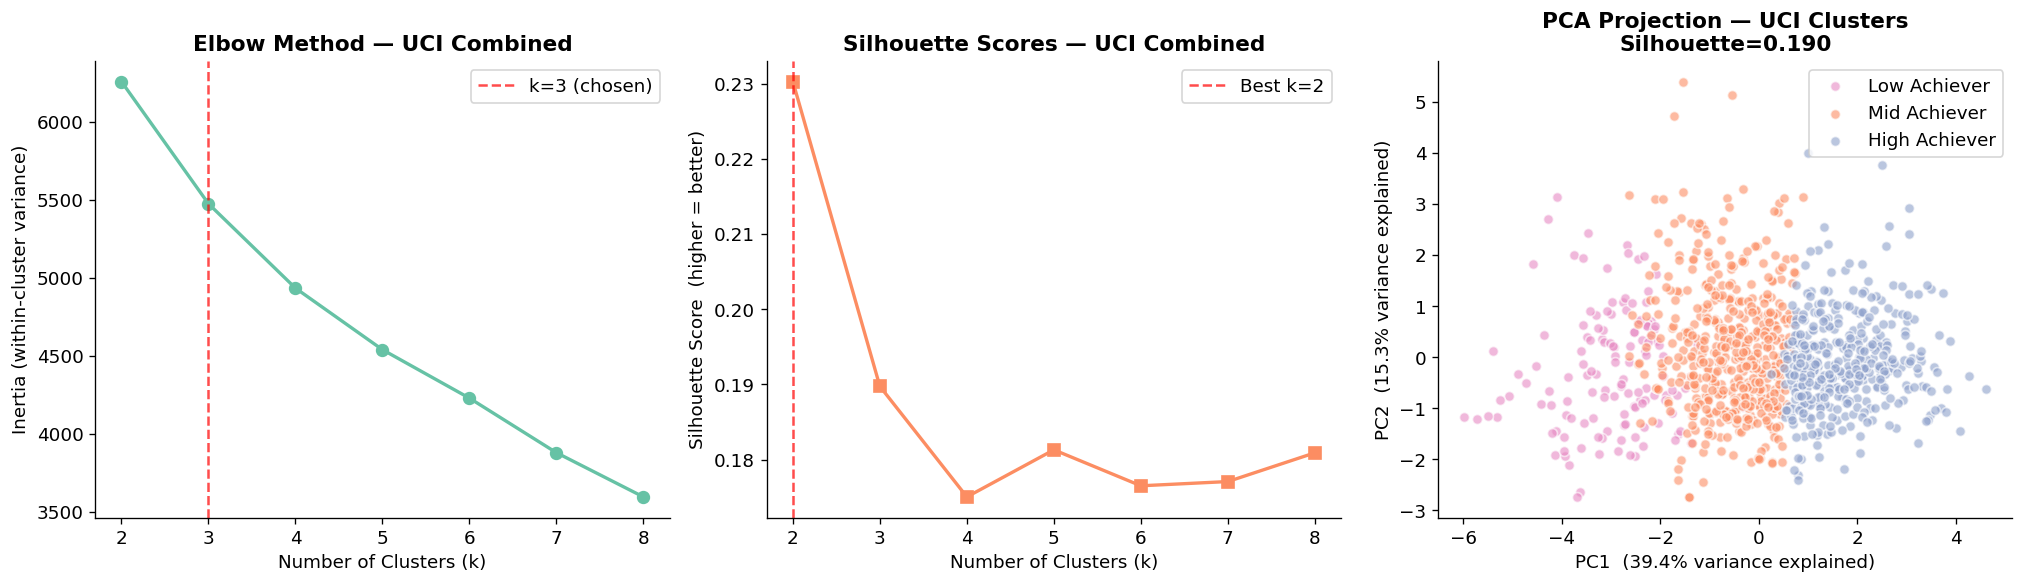

Figure 10 saved -> figures/fig10_uci_clustering.png


In [23]:

# K-MEANS UCI VISUALISATION  (Figure 10)

# Three subplots showing how we chose k and what the clusters look like.
#
# SUBPLOT 1 — Elbow Curve
#   X = number of clusters k  |  Y = inertia (within-cluster variance)
#   Inertia always decreases as k increases. The 'elbow' is where the
#   rate of decrease slows sharply — that is the natural cluster count.
#   Red dashed line marks k=3, our chosen value.
#
# SUBPLOT 2 — Silhouette Scores
#   Higher value = better-separated clusters.
#   The peak shows the k where clusters are most distinct from each other.
#   If the peak is at k=3, statistical and interpretability choices agree.
#   If it peaks at a different k, we are trading some statistical optimality
#   for the practical benefit of having 3 named learner profiles.
#
# SUBPLOT 3 — PCA Scatter Plot
#   K-Means ran in 8-dimensional feature space.
#   We use PCA (Principal Component Analysis) to REDUCE to 2 dimensions
#   FOR VISUALISATION ONLY — the clustering itself was done in full 8-D.
#   PC1 and PC2 capture the two directions of most variance in the data.
#   The % in axis labels shows how much variance each component explains.
#   Well-separated, non-overlapping coloured blobs = meaningful clusters.


print("Generating Figure 10: UCI Clustering Analysis...")

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Elbow curve
axes[0].plot(K_RANGE, inertia, 'o-', color=PALETTE[0], lw=2, ms=7)
axes[0].axvline(3, color='red', linestyle='--', alpha=0.7, label='k=3 (chosen)')
axes[0].set_title('Elbow Method — UCI Combined', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (within-cluster variance)')
axes[0].legend()

# Silhouette scores
axes[1].plot(K_RANGE, sil, 's-', color=PALETTE[1], lw=2, ms=7)
axes[1].axvline(best_k, color='red', linestyle='--', alpha=0.7, label=f'Best k={best_k}')
axes[1].set_title('Silhouette Scores — UCI Combined', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score  (higher = better)')
axes[1].legend()

# PCA scatter — visualise clusters in 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_uci_cl)
cluster_colors_uci = {'Low Achiever': PALETTE[3], 'Mid Achiever': PALETTE[1], 'High Achiever': PALETTE[2]}
for name, color in cluster_colors_uci.items():
    mask = uci_all['cluster_name'] == name
    axes[2].scatter(X_pca[mask,0], X_pca[mask,1], c=[color], label=name, alpha=0.6, s=35, edgecolors='white')
axes[2].set_title(f'PCA Projection — UCI Clusters\nSilhouette={sil_uci:.3f}', fontweight='bold')
axes[2].set_xlabel(f'PC1  ({pca.explained_variance_ratio_[0]*100:.1f}% variance explained)')
axes[2].set_ylabel(f'PC2  ({pca.explained_variance_ratio_[1]*100:.1f}% variance explained)')
axes[2].legend()
plt.tight_layout()
plt.savefig('figures/fig10_uci_clustering.png', bbox_inches='tight')
plt.show()
print("Figure 10 saved -> figures/fig10_uci_clustering.png")

### 7.2 Clustering on xAPI Behavioral Features

CLUSTERING 2: K-Means on xAPI Behavioral Features Only


  xAPI K-Means k=3 Silhouette: 0.3598

── Cluster vs Actual Class Cross-Tabulation ─────────────────────
  (shows whether unsupervised behavioral clusters align with labelled classes)
Class          H    L   M
cluster_name             
Active        77    0  60
Moderate      58   10  85
Passive        7  115  66

── Mean Engagement Score per Cluster ────────────────────────────
  Passive     : 22.41  (188 students)
  Moderate    : 50.39  (153 students)
  Active      : 72.85  (137 students)

Generating Figure 11: xAPI Clustering...


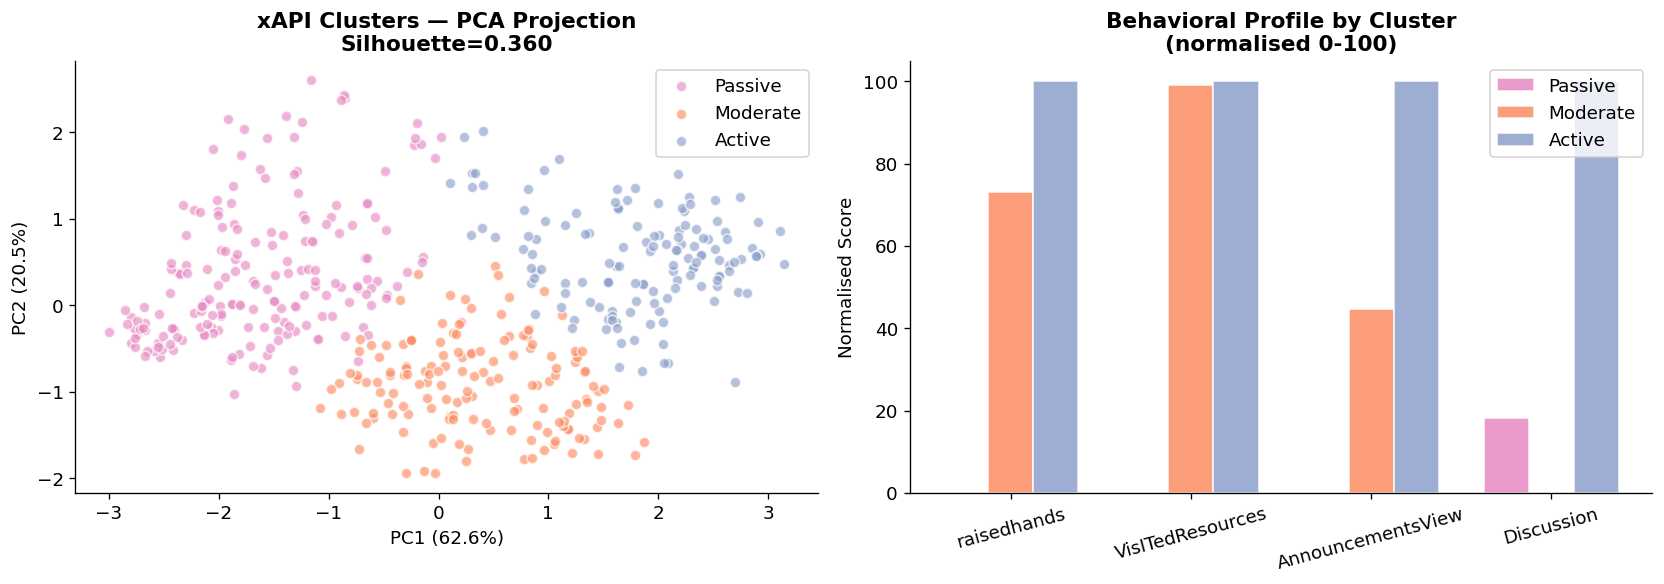

Figure 11 saved -> figures/fig11_xapi_clustering.png


In [24]:

# K-MEANS CLUSTERING: xAPI BEHAVIORAL  (Figure 11)

# A second clustering, applied ONLY to the 4 behavioral interaction counts.
# This is different from the UCI clustering in an important way:
#
# NO GRADE INFORMATION IS USED HERE.
# We cluster purely on what students DO (raise hands, visit resources,
# view announcements, discuss) — not on how they score.
#
# THE KEY RESEARCH QUESTION:
#   If we group students by behavior alone (no grade data), do the
#   resulting groups naturally align with the actual L/M/H class labels?
#   If yes -> behavioral engagement alone is sufficient to identify
#   performance level BEFORE any grades are available.
#   This has major implications for early intervention systems.
#
# VALIDATION — Cross-Tabulation:
#   After clustering, we compare cluster labels against actual Class labels.
#   A cluster where most students are Class H = Active learner cluster.
#   Strong alignment confirms that behavioral patterns predict outcomes.
#
# EXPECTED PROFILES:
#   Active   : high across all 4 behaviors, low absence, mostly Class H
#   Moderate : middle-range engagement, mixed absence and class
#   Passive  : low engagement, high absence, mostly Class L


print("=" * 60)
print("CLUSTERING 2: K-Means on xAPI Behavioral Features Only")
print("=" * 60)

scaler2  = StandardScaler()
X_xapi_cl = scaler2.fit_transform(df_x[BEHAV_COLS])

# Test k=2 through k=8
inertia2, sil2 = [], []
for k in K_RANGE:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_xapi_cl)
    inertia2.append(km.inertia_)
    sil2.append(silhouette_score(X_xapi_cl, lbl))

km_xapi = KMeans(n_clusters=3, random_state=42, n_init=10)
df_x['cluster'] = km_xapi.fit_predict(X_xapi_cl)
sil_xapi = silhouette_score(X_xapi_cl, df_x['cluster'])

# Label by engagement score: lowest = Passive
eng_by_c  = df_x.groupby('cluster')['engagement_score'].mean().sort_values()
cmap_xapi = {eng_by_c.index[0]: 'Passive', eng_by_c.index[1]: 'Moderate', eng_by_c.index[2]: 'Active'}
df_x['cluster_name'] = df_x['cluster'].map(cmap_xapi)

print(f"  xAPI K-Means k=3 Silhouette: {sil_xapi:.4f}")
print("\n── Cluster vs Actual Class Cross-Tabulation ─────────────────────")
print("  (shows whether unsupervised behavioral clusters align with labelled classes)")
ct_tab = pd.crosstab(df_x['cluster_name'], df_x['Class'])
print(ct_tab.to_string())
print("\n── Mean Engagement Score per Cluster ────────────────────────────")
for name in ['Passive','Moderate','Active']:
    m = df_x[df_x['cluster_name']==name]['engagement_score'].mean()
    n = (df_x['cluster_name']==name).sum()
    print(f"  {name:<12}: {m:.2f}  ({n} students)")

print("\nGenerating Figure 11: xAPI Clustering...")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pca2     = PCA(n_components=2, random_state=42)
X_pca2   = pca2.fit_transform(X_xapi_cl)
cluster_colors_x = {'Passive': PALETTE[3], 'Moderate': PALETTE[1], 'Active': PALETTE[2]}

for name, color in cluster_colors_x.items():
    mask = df_x['cluster_name'] == name
    axes[0].scatter(X_pca2[mask,0], X_pca2[mask,1], c=[color], label=name, alpha=0.65, s=40, edgecolors='white')
axes[0].set_title(f'xAPI Clusters — PCA Projection\nSilhouette={sil_xapi:.3f}', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend()

profile = df_x.groupby('cluster_name')[BEHAV_COLS].mean()
norm_p  = (profile - profile.min()) / (profile.max() - profile.min()) * 100
x_ = np.arange(len(BEHAV_COLS)); w_ = 0.25
for i, (name, color) in enumerate(cluster_colors_x.items()):
    axes[1].bar(x_ + i*w_, norm_p.loc[name], w_, label=name, color=color, edgecolor='white', alpha=0.85)
axes[1].set_xticks(x_+w_); axes[1].set_xticklabels(BEHAV_COLS, rotation=15)
axes[1].set_title('Behavioral Profile by Cluster\n(normalised 0-100)', fontweight='bold')
axes[1].set_ylabel('Normalised Score')
axes[1].legend()
plt.tight_layout()
plt.savefig('figures/fig11_xapi_clustering.png', bbox_inches='tight')
plt.show()
print("Figure 11 saved -> figures/fig11_xapi_clustering.png")

## 8. Association Rule Mining

Association rule mining finds **co-occurrence patterns**: *if a student has property A and property B, they tend to also have property C*. It was originally developed for supermarket basket analysis ('customers who buy bread and butter also buy milk'), but applies directly to student behaviour.

**How the Apriori algorithm works:**
1. Binarise continuous features at their median (e.g., `raised_hands` > median → `hands_high = 1`).
2. Count how often each combination of binary features appears together — this is **support**.
3. For each frequent pattern, calculate **confidence** (how often the rule's consequent follows) and **lift** (how much more likely the consequent is, compared to chance).

**What to look for:**
- High **lift** (> 1.5) means the association is genuinely informative, not just reflecting base rates.
- High **confidence** (> 0.6) means the rule fires reliably.
- Rules linking *behavioural inputs* to *class outcomes* are the most actionable — they suggest interventions educators can actually make.

### 8.1 xAPI Behavioral Rules

In [25]:

# ASSOCIATION RULE MINING: xAPI BEHAVIORAL RULES

# WHAT IS ASSOCIATION RULE MINING?
#   Originally from market basket analysis: "customers who buy bread
#   also tend to buy butter." Applied here: "students who raise hands
#   frequently AND visit many resources tend to be High-class performers."
#
# THREE KEY METRICS:
#   Support    : fraction of ALL students showing this pattern
#                min_support=0.12 -> must appear in at least 12% of students
#   Confidence : given the antecedent, how often does the consequent hold?
#                min_confidence=0.55 -> rule is correct at least 55% of the time
#   Lift       : how much MORE likely is the consequent given the antecedent,
#                compared to the baseline rate of the consequent alone?
#                Lift > 1 = the pattern genuinely predicts the outcome.
#                Lift = 1 = no relationship (coincidence).
#                We RANK by lift to find the most non-obvious patterns.
#
# DISCRETISATION (required by Apriori):
#   Apriori needs True/False items, not continuous numbers.
#   We split each behavioral feature at its MEDIAN:
#     raisedhands_high = True if raisedhands >= median, else False
#   Same for all 4 behaviors, absence flag, and parent survey.
#   Class outcomes become binary flags: class_high=True if Class=='H'.
#
# WE FILTER so the CONSEQUENT (right side of rule) is always a class outcome.
# These are the most actionable: "doing X leads to class Y."


print("=" * 60)
print("ASSOCIATION RULE MINING 1: xAPI Behavioral Patterns")
print("=" * 60)

df_arm = df_x.copy()

# Discretise at median values
print("  Discretising behavioral features at their medians:")
for col in BEHAV_COLS:
    threshold = df_arm[col].median()
    df_arm[f'{col}_high'] = (df_arm[col] >= threshold).astype(bool)
    print(f"    {col}_high: threshold = {threshold:.0f}")

# Binary class outcome flags
df_arm['class_low']   = (df_arm['Class'] == 'L')
df_arm['class_med']   = (df_arm['Class'] == 'M')
df_arm['class_high']  = (df_arm['Class'] == 'H')
df_arm['absent_high'] = (df_arm['StudentAbsenceDays'] == 'Above-7')
df_arm['parent_yes']  = (df_arm['ParentAnsweringSurvey'] == 'Yes')

arm_cols = ([f'{c}_high' for c in BEHAV_COLS] +
            ['absent_high','parent_yes','class_low','class_med','class_high'])
df_trans = df_arm[arm_cols].astype(bool)

# Run Apriori algorithm
freq_items = apriori(df_trans, min_support=0.12, use_colnames=True)
rules = association_rules(freq_items, metric='confidence', min_threshold=0.55)
rules = rules.sort_values('lift', ascending=False)

# Keep only rules where the outcome IS a class label
class_outcomes = {'class_low','class_med','class_high'}
outcome_rules  = rules[rules['consequents'].apply(lambda x: bool(set(x) & class_outcomes))].copy()

print(f"\n── Mining Results ───────────────────────────────────────────────")
print(f"  Frequent itemsets (support >= 0.12) : {len(freq_items)}")
print(f"  Total rules (confidence >= 0.55)    : {len(rules)}")
print(f"  Class-predicting rules              : {len(outcome_rules)}")
print("\n── Top 10 Rules by Lift ─────────────────────────────────────────")
print(outcome_rules[['antecedents','consequents','support','confidence','lift']].head(10).to_string(index=False))

ASSOCIATION RULE MINING 1: xAPI Behavioral Patterns
  Discretising behavioral features at their medians:
    raisedhands_high: threshold = 50
    VisITedResources_high: threshold = 65
    AnnouncementsView_high: threshold = 33
    Discussion_high: threshold = 40

── Mining Results ───────────────────────────────────────────────
  Frequent itemsets (support >= 0.12) : 88
  Total rules (confidence >= 0.55)    : 302
  Class-predicting rules              : 11

── Top 10 Rules by Lift ─────────────────────────────────────────
                                                                             antecedents             consequents  support  confidence     lift
                                                                frozenset({absent_high})  frozenset({class_low}) 0.238494    0.603175 2.306540
      frozenset({raisedhands_high, parent_yes, AnnouncementsView_high, Discussion_high}) frozenset({class_high}) 0.125523    0.588235 1.980116
                        frozenset({raisedhan

### 8.2 UCI Academic Rules (Math Dataset)

In [26]:

# ASSOCIATION RULE MINING: UCI ACADEMIC RULES

# A second round of Apriori, this time on the Math (UCI) dataset.
# Instead of behavioral features, we use academic habits and background:
#
#   studytime_high : studies more than median hours per week
#   absences_high  : more absences than median
#   failures_any   : has at least one past course failure (failures > 0)
#   alcohol_high   : avg_alcohol above median
#   higher_edu     : intends to pursue higher education
#
# Outcome flags: pass (G3 >= 10)  and  fail (G3 < 10)
#
# HOW THIS DIFFERS FROM xAPI RULES:
#   xAPI rules link ENGAGEMENT BEHAVIORS to performance CLASS.
#   UCI rules link ACADEMIC HABITS AND BACKGROUND to PASS/FAIL outcome.
#   Together they give two complementary perspectives:
#     "What students DO in the classroom" (xAPI)
#     "Who students are and how they study" (UCI)
#
# WHAT TO EXPECT:
#   High-lift rules should include combinations like:
#   - no failures + high study time  -> pass  (obvious but should be strong)
#   - high failures + high absences  -> fail  (clear risk combination)
#   - higher education aspiration    -> pass  (motivation matters)
#
#   Rules with lift > 1.5 are especially noteworthy — they mean the
#   combination of antecedents is a much stronger predictor than any
#   single feature alone.


print("=" * 60)
print("ASSOCIATION RULE MINING 2: UCI Academic Rules (Math)")
print("=" * 60)

df_uci_arm = df_mat_p.copy()

# Discretise academic features at medians
df_uci_arm['studytime_high'] = (df_uci_arm['studytime'] >= df_uci_arm['studytime'].median())
df_uci_arm['absences_high']  = (df_uci_arm['absences']  >= df_uci_arm['absences'].median())
df_uci_arm['failures_any']   = (df_uci_arm['failures']  >  0)
df_uci_arm['alcohol_high']   = (df_uci_arm['avg_alcohol'] >= df_uci_arm['avg_alcohol'].median())
df_uci_arm['higher_edu']     = (df_uci_arm['higher_enc'] == df_uci_arm['higher_enc'].max()) if 'higher_enc' in df_uci_arm.columns else (df_uci_arm['higher'] == 'yes')
df_uci_arm['pass']  = (df_uci_arm['pass_fail'] == 1)
df_uci_arm['fail']  = (df_uci_arm['pass_fail'] == 0)

uci_arm_cols = ['studytime_high','absences_high','failures_any','alcohol_high','higher_edu','pass','fail']
uci_arm_cols = [c for c in uci_arm_cols if c in df_uci_arm.columns]
df_uci_trans = df_uci_arm[uci_arm_cols].astype(bool)

freq_uci  = apriori(df_uci_trans, min_support=0.10, use_colnames=True)
rules_uci = association_rules(freq_uci, metric='confidence', min_threshold=0.60)
rules_uci = rules_uci.sort_values('lift', ascending=False)
outcome_uci = rules_uci[rules_uci['consequents'].apply(lambda x: bool({'pass','fail'} & set(x)))].copy()

print(f"\n── Mining Results ───────────────────────────────────────────────")
print(f"  Frequent itemsets (support >= 0.10) : {len(freq_uci)}")
print(f"  Total rules (confidence >= 0.60)    : {len(rules_uci)}")
print(f"  Pass/fail predicting rules          : {len(outcome_uci)}")
print("\n── Top 10 Rules by Lift ─────────────────────────────────────────")
print(outcome_uci[['antecedents','consequents','support','confidence','lift']].head(10).to_string(index=False))

ASSOCIATION RULE MINING 2: UCI Academic Rules (Math)

── Mining Results ───────────────────────────────────────────────
  Frequent itemsets (support >= 0.10) : 56
  Total rules (confidence >= 0.60)    : 111
  Pass/fail predicting rules          : 25

── Top 10 Rules by Lift ─────────────────────────────────────────
                                             antecedents                   consequents  support  confidence     lift
                 frozenset({alcohol_high, failures_any})             frozenset({fail}) 0.101266    0.677966 2.059974
                               frozenset({failures_any})             frozenset({fail}) 0.131646    0.626506 1.903614
                   frozenset({failures_any, higher_edu})             frozenset({fail}) 0.106329    0.600000 1.823077
   frozenset({studytime_high, alcohol_high, higher_edu})             frozenset({pass}) 0.283544    0.708861 1.056604
               frozenset({studytime_high, alcohol_high}) frozenset({pass, higher_edu}) 0.283544   

Generating Figure 12: Association Rules Scatter Plots...


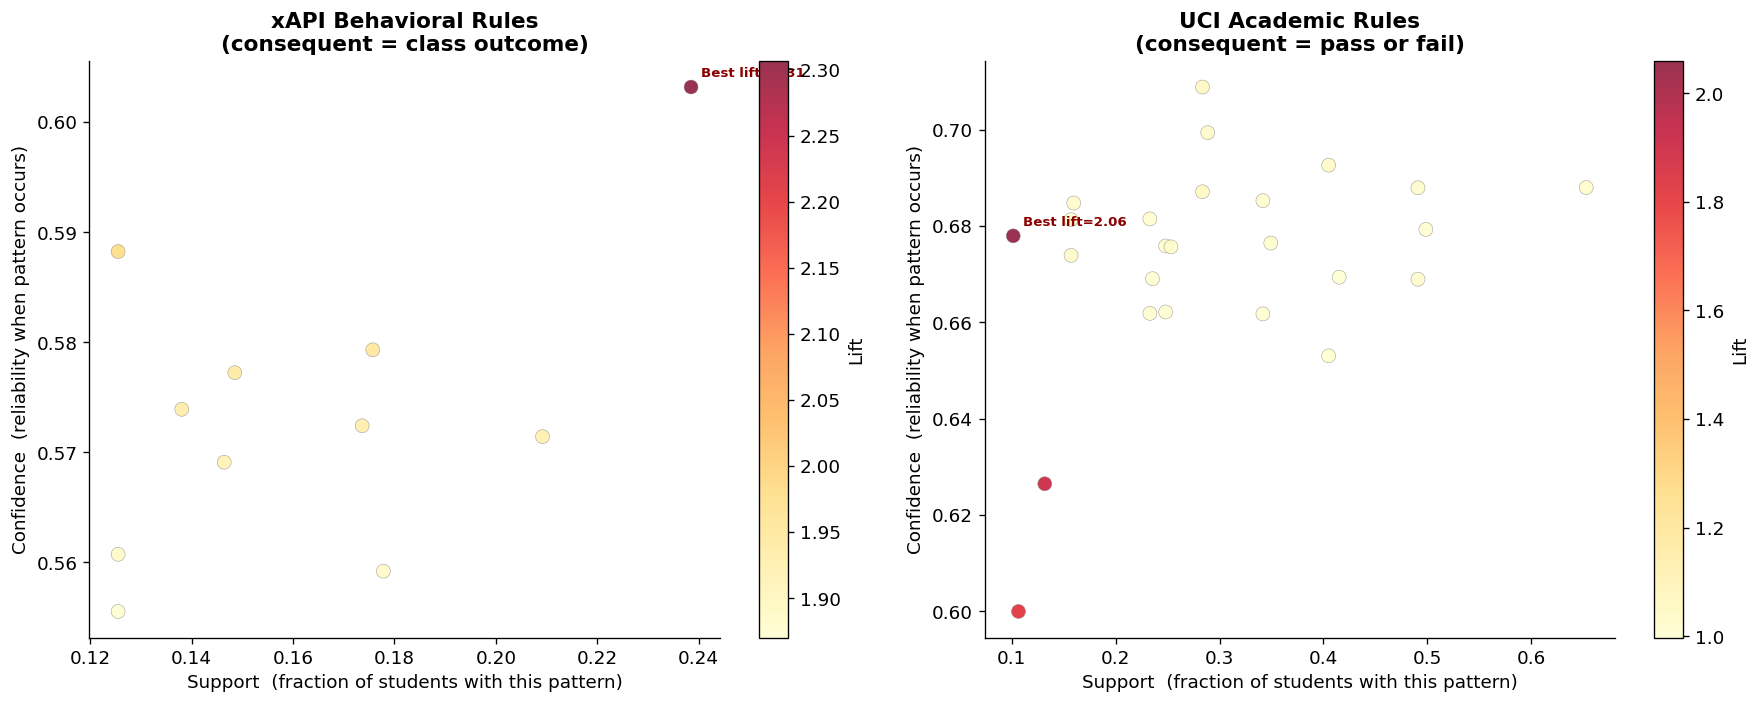

Figure 12 saved -> figures/fig12_association_rules.png


In [27]:

# ASSOCIATION RULES VISUALISATION  (Figure 12)

# Two scatter plots, one per rule set (xAPI and UCI), side by side.
#
# HOW TO READ EACH SCATTER PLOT:
#   Each point = one association rule
#   X-axis : Support    (how common is this pattern across all students?)
#   Y-axis : Confidence (how reliable is the rule when the pattern appears?)
#   Colour : Lift       (how non-obvious / surprising is the rule?)
#             Yellow = low lift  |  Orange = medium  |  Red = high lift
#
# THE MOST ACTIONABLE RULES are in the TOP-RIGHT CORNER with HIGH LIFT:
#   Top-right  = pattern is common AND the rule fires reliably
#   High lift  = the outcome is specifically linked to this combination,
#                not just because that outcome is common generally
#
# BOTTOM-LEFT rules are either rare (low support) or unreliable
# (low confidence) — less useful for practical recommendations.
#
# The annotated point shows the single rule with the highest lift value.


print("Generating Figure 12: Association Rules Scatter Plots...")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, rules_df, title in [
    (axes[0], outcome_rules, 'xAPI Behavioral Rules\n(consequent = class outcome)'),
    (axes[1], outcome_uci,   'UCI Academic Rules\n(consequent = pass or fail)'),
]:
    if len(rules_df) == 0:
        ax.text(0.5, 0.5, 'No rules found at current thresholds',
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title, fontweight='bold')
        continue
    sc = ax.scatter(rules_df['support'], rules_df['confidence'],
                    c=rules_df['lift'], cmap='YlOrRd', s=70, alpha=0.8,
                    edgecolors='grey', linewidth=0.3)
    plt.colorbar(sc, ax=ax, label='Lift')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Support  (fraction of students with this pattern)')
    ax.set_ylabel('Confidence  (reliability when pattern occurs)')
    # Annotate the highest-lift rule
    best = rules_df.loc[rules_df['lift'].idxmax()]
    ax.annotate(f"Best lift={best['lift']:.2f}",
                (best['support'], best['confidence']),
                textcoords='offset points', xytext=(6,6),
                fontsize=8, color='darkred', fontweight='bold')

plt.tight_layout()
plt.savefig('figures/fig12_association_rules.png', bbox_inches='tight')
plt.show()
print("Figure 12 saved -> figures/fig12_association_rules.png")

## 9. Statistical Tests & Cross-Dataset Insights

Visualisations reveal patterns; statistical tests tell us whether those patterns are **real or coincidental**.

This section runs two types of checks:

1. **Paired t-test (Math vs Portuguese grades)** — Tests whether the grade gap between subjects for dual-enrolled students is statistically significant, or just sampling noise. A p-value below 0.05 means we can reject the null hypothesis that average grades are equal.

2. **Point-biserial correlation** — Measures the strength of the relationship between a continuous variable (e.g., study time, absences) and a binary outcome (pass/fail). This gives us a correlation coefficient r and a p-value, so we can rank predictors by both *strength* and *confidence*.

3. **Kruskal-Wallis test (xAPI)** — A non-parametric test that checks whether the engagement score distributions are significantly different across the three performance classes (L/M/H). Non-parametric means it does not assume the data is normally distributed — safer for behavioural count data.

> **Rule of thumb**: p < 0.001 means the finding is very unlikely to be a fluke. p < 0.05 is the conventional threshold. Report both the effect size (r, difference in means) *and* the p-value — a tiny p-value on a huge dataset can come from a trivially small effect.

In [28]:

# STATISTICAL SIGNIFICANCE TESTS

# Visualisations show patterns. Statistical tests confirm whether those
# patterns are REAL or could have appeared by chance in our sample.
#
# TEST 1 — Paired t-test: Math G3 vs Portuguese G3
#   For 382 dual-enrolled students, each contributes one Math grade and
#   one Portuguese grade. We test if the MEAN DIFFERENCE is significant.
#   'Paired' because the two samples are NOT independent — same people.
#   H0 (null hypothesis): mean Math G3 = mean Portuguese G3
#
# TEST 2 — Independent t-test: High vs Low engagement (xAPI)
#   Two independent groups: Class H students and Class L students.
#   We test whether their mean engagement scores differ significantly.
#   This validates the visual separation seen in Figure 5.
#   H0: mean engagement is the same for Class H and Class L
#
# TEST 3 — Pearson Correlations: Math G3 vs all key features
#   r = correlation coefficient (-1 to +1)
#   p = probability of seeing this |r| by chance if the true r=0
#   p < 0.05  : statistically significant at 5% level  (*)
#   p < 0.001 : highly significant, very unlikely by chance (***)
#
# TEST 4 — Cross-subject Pearson: Math G3 vs Portuguese G3
#   Quantifies the cross-subject relationship for dual-enrolled students.


print("=" * 60)
print("STATISTICAL SIGNIFICANCE TESTS")
print("=" * 60)

# TEST 1: Paired t-test — same students, two subjects
t1, p1 = stats.ttest_rel(df_both_p['G3_math'], df_both_p['G3_port'])
print(f"\n[TEST 1] Paired t-test — Math G3 vs Portuguese G3  (n={len(df_both_p)})")
print(f"  H0: mean Math G3 = mean Portuguese G3")
print(f"  t = {t1:.3f},  p = {p1:.4e}")
print(f"  Mean Math G3 = {df_both_p.G3_math.mean():.2f}  |  Mean Portuguese G3 = {df_both_p.G3_port.mean():.2f}")
print(f"  Conclusion: {'REJECT H0 — significant difference' if p1<0.05 else 'FAIL TO REJECT H0'}  (alpha=0.05)")

# TEST 2: Independent t-test — High vs Low class engagement
high_eng = df_x[df_x['Class']=='H']['engagement_score']
low_eng  = df_x[df_x['Class']=='L']['engagement_score']
t2, p2   = stats.ttest_ind(high_eng, low_eng)
print(f"\n[TEST 2] Independent t-test — High vs Low class engagement  (xAPI)")
print(f"  H0: mean engagement is the same for Class H and Class L")
print(f"  t = {t2:.3f},  p = {p2:.4e}")
print(f"  Mean High = {high_eng.mean():.2f}  |  Mean Low = {low_eng.mean():.2f}  |  Difference = {high_eng.mean()-low_eng.mean():.2f}")
print(f"  Conclusion: {'REJECT H0 — engagement differs significantly' if p2<0.05 else 'FAIL TO REJECT H0'}")

# TEST 3: Pearson correlations — Math G3 vs features
print(f"\n[TEST 3] Pearson Correlations with Math Final Grade (G3)")
print(f"  {'Feature':<25}  {'r':>7}  {'p-value':>12}  Significant?")
print(f"  {'-'*60}")
for col in ['studytime','failures','absences','avg_alcohol','parent_edu_avg','G1','G2']:
    if col in df_mat_p.columns:
        r, p = stats.pearsonr(df_mat_p[col], df_mat_p['G3'])
        sig  = '*** (p<0.001)' if p<0.001 else ('* (p<0.05)' if p<0.05 else 'no')
        print(f"  {col:<25}  {r:>+7.3f}  {p:>12.4e}  {sig}")

# TEST 4: Cross-subject correlation
r_cross, p_cross = stats.pearsonr(df_both_p['G3_math'], df_both_p['G3_port'])
print(f"\n[TEST 4] Cross-subject correlation: Math G3 ~ Portuguese G3  (n={len(df_both_p)})")
print(f"  r = {r_cross:.3f},  p = {p_cross:.4e}")
print(f"  Interpretation: moderate-to-strong positive relationship.")
print(f"  Students who do well in one subject tend to do well in the other.")
print(f"  Performance is largely a student-level trait, not subject-specific.")

STATISTICAL SIGNIFICANCE TESTS

[TEST 1] Paired t-test — Math G3 vs Portuguese G3  (n=382)
  H0: mean Math G3 = mean Portuguese G3
  t = -9.977,  p = 5.5615e-21
  Mean Math G3 = 10.39  |  Mean Portuguese G3 = 12.52
  Conclusion: REJECT H0 — significant difference  (alpha=0.05)

[TEST 2] Independent t-test — High vs Low class engagement  (xAPI)
  H0: mean engagement is the same for Class H and Class L
  t = 24.903,  p = 2.3315e-71
  Mean High = 64.02  |  Mean Low = 20.49  |  Difference = 43.53
  Conclusion: REJECT H0 — engagement differs significantly

[TEST 3] Pearson Correlations with Math Final Grade (G3)
  Feature                          r       p-value  Significant?
  ------------------------------------------------------------
  studytime                   +0.098    5.2061e-02  no
  failures                    -0.360    1.4657e-13  *** (p<0.001)
  absences                    +0.034    4.9733e-01  no
  avg_alcohol                 -0.058    2.4813e-01  no
  parent_edu_avg          

Generating Figure 13: Study Time vs Final Grade (Math and Portuguese)...


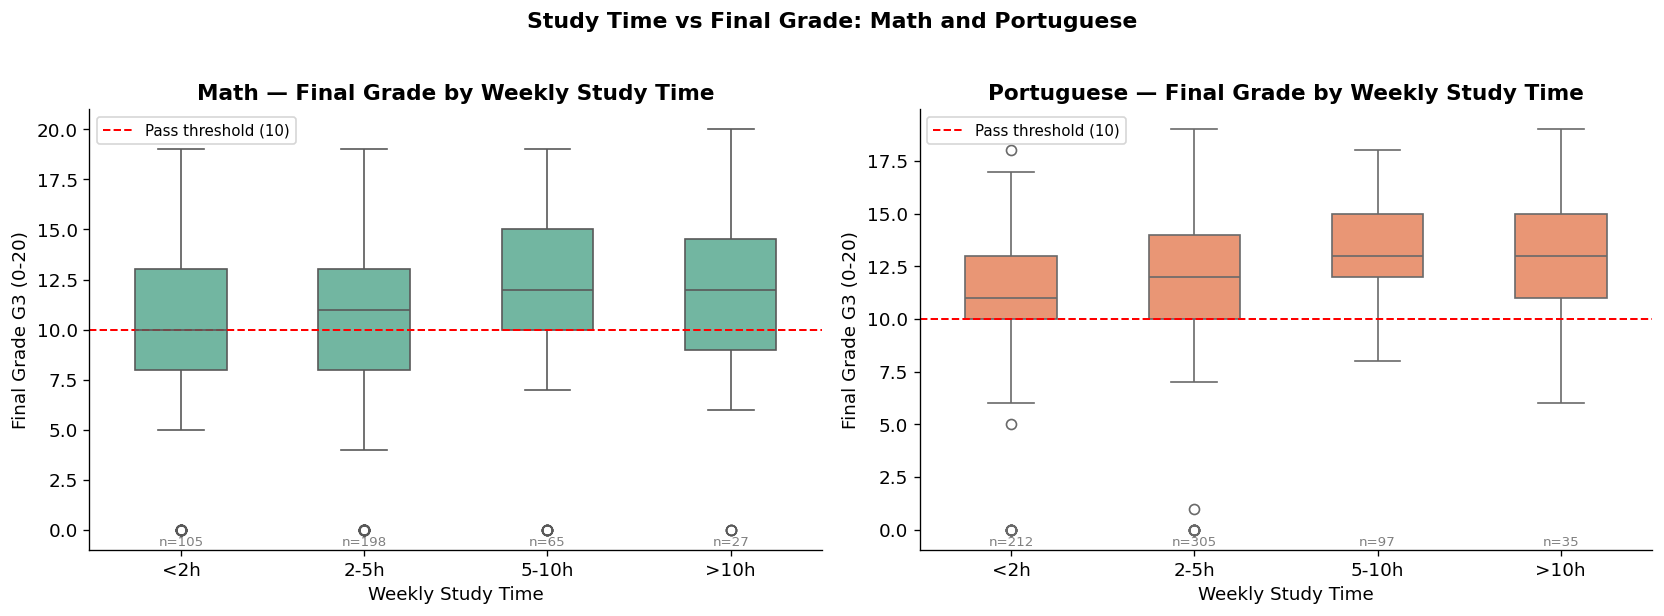


── Effect Size: Study Time on Grade ────────────────────────────
  Math: <2h avg G3=10.05  vs  5h+ avg G3=11.36  (difference = +1.31 pts)
  Portuguese: <2h avg G3=10.84  vs  5h+ avg G3=13.18  (difference = +2.34 pts)
Figure 13 saved -> figures/fig13_studytime_vs_grade.png


In [29]:

# CROSS-DATASET INSIGHT: STUDY TIME vs GRADE  (Figure 13)

# This figure translates a key statistical finding (study time correlates
# with G3) into a clear, educator-friendly visual.
#
# Math (left) and Portuguese (right) shown side by side — same format.
#
# HOW TO READ EACH BOXPLOT:
#   X-axis : study time category (<2h, 2-5h, 5-10h, >10h per week)
#   Y-axis : final grade G3 (0-20 scale)
#   Red dashed line : pass threshold (Grade = 10)
#   Each box shows:
#     - Middle line  : MEDIAN grade for that study time group
#     - Box height   : interquartile range (where middle 50% of students land)
#     - Whiskers     : range excluding outliers
#     - Dots         : individual outlier students
#   n=XX labels at the bottom show how many students are in each group.
#
# WHAT TO LOOK FOR:
#   - Do median grades consistently rise with more study time?
#   - Are the boxes for >10h students mostly above the pass threshold?
#   - Is the effect stronger for Math than Portuguese (or vice versa)?
#   - Are there diminishing returns between 5-10h and >10h groups?
#
# This is one of the most directly actionable charts in the notebook:
# it provides a simple, visual answer to "what should a struggling student do?"


print("Generating Figure 13: Study Time vs Final Grade (Math and Portuguese)...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (df, subj, color) in zip(axes, [
    (df_mat_p, 'Math',       SUBJECT_COLORS['Math']),
    (df_por_p, 'Portuguese', SUBJECT_COLORS['Portuguese'])
]):
    labels = {1:'<2h', 2:'2-5h', 3:'5-10h', 4:'>10h'}
    order  = ['<2h','2-5h','5-10h','>10h']
    df_tmp = df.copy()
    df_tmp['study_label'] = df_tmp['studytime'].map(labels)
    order_present = [o for o in order if o in df_tmp['study_label'].unique()]
    counts = df_tmp['study_label'].value_counts()

    sns.boxplot(data=df_tmp, x='study_label', y='G3', order=order_present,
                color=color, ax=ax, width=0.5)
    ax.axhline(10, color='red', linestyle='--', lw=1.2, label='Pass threshold (10)')
    ax.set_title(f'{subj} — Final Grade by Weekly Study Time', fontweight='bold')
    ax.set_xlabel('Weekly Study Time')
    ax.set_ylabel('Final Grade G3 (0-20)')
    ax.legend(fontsize=9)

    # Show student count below each box
    for i, cat in enumerate(order_present):
        n = counts.get(cat, 0)
        ax.text(i, ax.get_ylim()[0]+0.2, f'n={n}', ha='center', fontsize=8, color='grey')

plt.suptitle('Study Time vs Final Grade: Math and Portuguese', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/fig13_studytime_vs_grade.png', bbox_inches='tight')
plt.show()

print("\n── Effect Size: Study Time on Grade ────────────────────────────")
for df, subj in [(df_mat_p,'Math'),(df_por_p,'Portuguese')]:
    labels = {1:'<2h', 2:'2-5h', 3:'5-10h', 4:'>10h'}
    df_tmp = df.copy()
    df_tmp['study_label'] = df_tmp['studytime'].map(labels)
    low_g3  = df_tmp[df_tmp['study_label']=='<2h']['G3'].mean()
    high_g3 = df_tmp[df_tmp['study_label'].isin(['>10h','5-10h'])]['G3'].mean()
    print(f"  {subj}: <2h avg G3={low_g3:.2f}  vs  5h+ avg G3={high_g3:.2f}  (difference = {high_g3-low_g3:+.2f} pts)")
print("Figure 13 saved -> figures/fig13_studytime_vs_grade.png")

### 9.3 Additional Statistics Reported in the Paper

The paper also reports a Kruskal-Wallis test across the three xAPI classes and Davies-Bouldin scores for both clusterings. They are computed here so that every number in the paper can be reproduced from this notebook.

In [30]:

# ADDITIONAL STATISTICS FOR THE PAPER

# KRUSKAL-WALLIS TEST
#   Non-parametric alternative to one-way ANOVA: are engagement scores
#   different across the Low / Medium / High classes? It compares ranks,
#   so it does not assume the scores are normally distributed.
#
# DAVIES-BOULDIN INDEX
#   Average similarity between each cluster and its closest neighbour.
#   LOWER is better (tighter, better-separated clusters). Complements
#   the silhouette score reported in Section 7.

from sklearn.metrics import davies_bouldin_score

groups = [df_x[df_x['Class'] == c]['engagement_score'] for c in ['L', 'M', 'H']]
h_stat, h_p = stats.kruskal(*groups)
print("[TEST 3] Kruskal-Wallis — engagement score across L / M / H classes")
print(f"  H = {h_stat:.1f},  p = {h_p:.3e}")

db_uci  = davies_bouldin_score(X_uci_cl,  uci_all['cluster'])
db_xapi = davies_bouldin_score(X_xapi_cl, df_x['cluster'])
print("\n── Davies-Bouldin Index (k=3, lower = better) ─────────────────")
print(f"  UCI  : {db_uci:.3f}   (silhouette {sil_uci:.3f})")
print(f"  xAPI : {db_xapi:.3f}   (silhouette {sil_xapi:.3f})")

ratio_hands = (df_x[df_x['Class'] == 'H']['raisedhands'].mean() /
               df_x[df_x['Class'] == 'L']['raisedhands'].mean())
print(f"\n  High vs Low class — mean raised hands ratio: {ratio_hands:.1f}x")


[TEST 3] Kruskal-Wallis — engagement score across L / M / H classes
  H = 239.0,  p = 1.288e-52

── Davies-Bouldin Index (k=3, lower = better) ─────────────────
  UCI  : 1.686   (silhouette 0.190)
  xAPI : 1.094   (silhouette 0.360)

  High vs Low class — mean raised hands ratio: 4.2x


## 10. Final Summary

In [31]:

# FINAL SUMMARY

# This cell collects all key numerical results computed throughout the
# notebook and prints them in one structured summary.
#
# USE THIS OUTPUT TO FILL IN THE LATEX REPORT (report.tex):
#   Model accuracy / AUC values  ->  Table I in Section V (Results)
#   CV accuracy mean +/- std     ->  same table
#   Silhouette scores             ->  Section V-C (Clustering)
#   Association rule counts       ->  Section V-D (Association Rules)
#   Cross-subject r and grade gap ->  Section V-A (EDA)
#   Best rule antecedents/lift    ->  Section V-D narrative


import glob

print("=" * 65)
print("ANALYSIS SUMMARY — THREE-DATASET STUDY")
print("=" * 65)

print(f"\n── DATASETS {'─'*40}")
print(f"  Math         : {df_mat.shape[0]} students | {df_mat.shape[1]} features | Pass rate {(df_mat.G3>=10).mean()*100:.1f}%")
print(f"  Portuguese   : {df_por.shape[0]} students | {df_por.shape[1]} features | Pass rate {(df_por.G3>=10).mean()*100:.1f}%")
print(f"  Dual-enrolled: {df_both.shape[0]} students in both courses")
print(f"  xAPI         : {df_xapi.shape[0]} students | {df_xapi.shape[1]} features")

print(f"\n── SUPERVISED MODELS {'─'*34}")
print(f"  {'Model':<20} {'Accuracy':>10}  {'AUC-ROC':>9}  {'5-Fold CV':>18}")
print(f"  {'─'*62}")
print(f"  {'Math RF':<20} {acc_m*100:>9.2f}%  {auc_m:>9.4f}  {cv_m.mean()*100:.2f}% +/- {cv_m.std()*100:.2f}%")
print(f"  {'Portuguese RF':<20} {acc_p*100:>9.2f}%  {auc_p:>9.4f}  {cv_p.mean()*100:.2f}% +/- {cv_p.std()*100:.2f}%")
print(f"  {'xAPI GB (3-class)':<20} {acc_gb*100:>9.2f}%  {auc_gb:>9.4f}  {cv_gb.mean()*100:.2f}% +/- {cv_gb.std()*100:.2f}%")

print(f"\n── BASELINES & EARLY WARNING (Random Forest) {'─'*10}")
for subj in ['Math', 'Portuguese']:
    b = baseline_results[subj].set_index('Model')
    e = early_results[subj].set_index('Model')
    print(f"  {subj:<11} rule G2>=10: {b.loc['Rule: G2 >= 10','Accuracy']:.2f}%  |  "
          f"RF all features: {b.loc['Random Forest','Accuracy']:.2f}%  |  "
          f"RF no grades: {e.loc['Random Forest','Accuracy']:.2f}% (AUC {e.loc['Random Forest','AUC']:.3f})")

print(f"\n── CLUSTERING {'─'*42}")
print(f"  UCI  K-Means k=3  Silhouette: {sil_uci:.4f}  ->  Low / Mid / High Achiever")
print(f"  xAPI K-Means k=3  Silhouette: {sil_xapi:.4f}  ->  Passive / Moderate / Active")

print(f"\n── ASSOCIATION RULES {'─'*34}")
print(f"  xAPI class-predicting rules : {len(outcome_rules)}")
print(f"  UCI  pass/fail rules        : {len(outcome_uci)}")
if len(outcome_rules) > 0:
    b = outcome_rules.iloc[0]
    print(f"  Best xAPI rule: lift={b['lift']:.3f}, conf={b['confidence']:.3f}")
    print(f"    {set(b['antecedents'])}  ->  {set(b['consequents'])}")
if len(outcome_uci) > 0:
    b = outcome_uci.iloc[0]
    print(f"  Best UCI rule:  lift={b['lift']:.3f}, conf={b['confidence']:.3f}")
    print(f"    {set(b['antecedents'])}  ->  {set(b['consequents'])}")

print(f"\n── CROSS-SUBJECT {'─'*38}")
print(f"  Math vs Portuguese G3 correlation : r = {r_cross:.3f}")
print(f"  Mean grade gap (Math - Portuguese) : {df_both_p.grade_gap.mean():.2f} points")
print(f"  Students passing BOTH subjects     : {df_both_p.pass_both.mean()*100:.1f}%")

print(f"\n── FIGURES SAVED TO ./figures/ {'─'*24}")
saved = sorted(glob.glob('figures/fig*.png'))
for f in saved:
    kb = os.path.getsize(f) // 1024
    print(f"  {f}  ({kb} KB)")

print("\n" + "=" * 65)
print("Copy the numbers above into report.tex to complete the paper.")
print("=" * 65)

ANALYSIS SUMMARY — THREE-DATASET STUDY

── DATASETS ────────────────────────────────────────
  Math         : 395 students | 33 features | Pass rate 67.1%
  Portuguese   : 649 students | 33 features | Pass rate 84.6%
  Dual-enrolled: 382 students in both courses
  xAPI         : 478 students | 17 features

── SUPERVISED MODELS ──────────────────────────────────
  Model                  Accuracy    AUC-ROC           5-Fold CV
  ──────────────────────────────────────────────────────────────
  Math RF                  86.08%     0.9419  90.89% +/- 2.45%
  Portuguese RF            87.69%     0.9364  92.45% +/- 0.90%
  xAPI GB (3-class)        76.04%     0.9202  73.85% +/- 6.29%

── BASELINES & EARLY WARNING (Random Forest) ──────────
  Math        rule G2>=10: 87.34%  |  RF all features: 86.08%  |  RF no grades: 68.35% (AUC 0.627)
  Portuguese  rule G2>=10: 90.77%  |  RF all features: 87.69%  |  RF no grades: 78.46% (AUC 0.662)

── CLUSTERING ──────────────────────────────────────────
  UC